# Global Field Mechanism — Comprehensive Evaluation
**Benchmarks:** sMNIST / psMNIST | **Hidden:** 16 / 32 | **Conditions:** Passive / Probe / Active

This notebook:
1. Loads JSON result logs from all four experiment configurations
2. Plots metric trajectories and final-epoch comparisons across all configs
3. Loads trained weights and runs saliency mapping per digit
4. Visualises hidden-state dynamics ("inside the brain") for representative inputs
5. Generates coordination-without-collapse scatter plots

## 0. Imports

In [1]:
import os, json, math, gc, random
import numpy as np
import scipy.linalg
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.lines import Line2D
import matplotlib.cm as cm
import tensorflow as tf
import json
import os
import numpy as np
import json
import os

def load_json(cfg_key, cond):
    """Load the JSON result file for a specific config and condition."""
    cfg = CONFIGS[cfg_key]
    folder = cfg['folder']
    filename = cfg['json'].get(cond)
    
    if not filename:
        print(f"     No JSON filename defined for {cfg_key} | {cond}")
        return None
        
    path = os.path.join(folder, filename)
    
    if os.path.exists(path):
        with open(path, 'r') as f:
            return json.load(f)
    else:
        print(f"     File not found: {path}")
        return None

# Suppress TF noise
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
tf.keras.mixed_precision.set_global_policy('float32')
print('TF:', tf.__version__)

"""Return dict of numpy arrays from a loaded JSON result."""
import os
import json
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

def extract_series(data):
    """Return dict of numpy arrays from a loaded JSON result with normalized keys."""
    # 1. Locate history list
    h_list = data.get('history') or data.get('epochs')
    if h_list is None: return None

    # 2. Extract raw metrics based on structure
    if isinstance(h_list, dict):  # sMNIST/psMNIST style (dict of lists)
        raw_h = h_list
        epochs = np.arange(1, len(raw_h['loss']) + 1)
        loss = np.array(raw_h['loss'])
        val_metric = np.array(raw_h.get('acc') or raw_h.get('mse') or [0])
        
        # Flatten hidden_metrics if they exist
        if 'hidden_metrics' in raw_h and len(raw_h['hidden_metrics']) > 0:
            extracted_metrics = {k: np.array([m[k] for m in raw_h['hidden_metrics']])
                                 for k in raw_h['hidden_metrics'][0]}
        else:
            extracted_metrics = {}
    else:  # Adding/CIFAR style (list of dicts)
        epochs = np.array([e['epoch'] for e in h_list])
        loss = np.array([e.get('loss') or e.get('mse') for e in h_list])
        val_metric = np.array([e.get('acc') or e.get('mse') for e in h_list])
        
        excluded = {'epoch', 'loss', 'mse', 'acc'}
        metric_keys = [k for k in h_list[0].keys() if k not in excluded]
        extracted_metrics = {k: np.array([e[k] for e in h_list]) for k in metric_keys}

    # 3. NORMALIZE KEYS (Map sMNIST long names to short names used in plotting)
    key_map = {
        'effective_rank': 'rank',
        'synchrony':      'sync',
        'interference':   'intf',
        'entropy':        'entr'
    }
    normalized_metrics = {}
    for k, v in extracted_metrics.items():
        norm_k = key_map.get(k, k) # Use map if exists, else keep original
        normalized_metrics[norm_k] = v

    # 4. Handle Accuracy/MSE for test results
    # Check all common variants of the test result key
    test_val = (data.get('test_acc') or data.get('test_accuracy') or 
                data.get('test_mse') or data.get('test_loss') or 0.0)
    
    # Auto-scale accuracy to % (0.85 -> 85.0)
    is_acc = any(k in data for k in ['test_acc', 'test_accuracy', 'acc'])
    test_result_final = test_val * 100 if (is_acc and test_val <= 1.0) else test_val

    return {
        'epochs':       epochs,
        'loss':         loss,
        'val_metric':   val_metric * 100 if (is_acc and val_metric[0] <= 1.0) else val_metric,
        'test_acc':     test_result_final, 
        'config':       data.get('parameters', data.get('config')),
        **normalized_metrics
    }

2026-05-03 14:47:11.433899: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-05-03 14:47:11.441209: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777783631.451046   87928 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777783631.454634   87928 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777783631.462016   87928 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

TF: 2.19.1


## 1. Path Configuration

In [2]:
# ------------------------------------------------------------------ #
#  EDIT: set the four root folders for each experiment configuration  #
# ------------------------------------------------------------------ #
BASE = '/home/casper/Documents/A_Casper/Brein/CS_Ai_Wolfhampton/Dissertation'

CONFIGS = {
    'psMNIST-H32': {
        'folder': f'{BASE}/PMNIST/h32',
        'hidden': 32,
        'benchmark': 'psMNIST',
        'permuted': True,
        # Session IDs for each condition (edit to match your filenames)
        'sessions': {
            'Active':  'RES_H32_S0.13_J1_260221_2142',
            'Passive': 'RES_H32_S0.13_J1_260222_1954',
            'Probe':   'RES_H32_S0.13_J1_260222_1954',
        },
        # Exact weight file names (with copy suffixes etc.)
        'weights': {
            'Active':  'best_RES_H32_S0.13_J1_260221_2142_active.weights.h5',
            'Passive': 'best_RES_H32_S0.13_J1_260222_1954_passive.weights.h5',
            'Probe':   'best_RES_H32_S0.13_J1_260222_1954_probe.weights.h5',
        },
        'json': {
            'Active':  'results_RES_H32_S0.13_J1_260221_2142_Active.json',
            'Passive': 'results_RES_H32_S0.13_J1_260222_1954_Passive.json',
            'Probe':   'results_RES_H32_S0.13_J1_260222_1954_Probe.json',
        },
        # Hyperparams used during this run
        'hparams': dict(BASE_STRENGTH=0.13, JITTER_SCALE=1.0, PERIOD=392.0,
                        LAMBDA_SLOW=0.0075, REST_BASELINE=1.0,
                        H_SCALE=[0.85, 0.15]),
    },
    'psMNIST-H16': {
        'folder': f'{BASE}/PMNIST/h16',
        'hidden': 16,
        'benchmark': 'psMNIST',
        'permuted': True,
        'sessions': {
            'Active':  'RES_H16_S0.13_J0.65_260223_1436',  
            'Passive': 'RES_H16_S0.13_J0.65_260223_1436',
            'Probe':   'RES_H16_S0.13_J0.65_260223_1436',
        },
        'weights': {
            'Active':  'best_RES_H16_S0.13_J0.65_260223_1436_active.weights.h5',  
            'Passive': 'best_RES_H16_S0.13_J0.65_260223_1436_passive.weights.h5',
            'Probe':   'best_RES_H16_S0.13_J0.65_260223_1436_probe.weights.h5',
        },
        'json': {
            'Active':  'results_RES_H16_S0.13_J0.65_260223_1436_Active.json',   
            'Passive': 'results_RES_H16_S0.13_J0.65_260223_1436_Passive.json',
            'Probe':   'results_RES_H16_S0.13_J0.65_260223_1436_Probe.json',
        },
        'hparams': dict(BASE_STRENGTH=0.13, JITTER_SCALE=0.65, PERIOD=196.0,
                        LAMBDA_SLOW=0.015, REST_BASELINE=1.0,
                        H_SCALE=[0.94, 0.06]),
    },
    'sMNIST-H32': {
        'folder': f'{BASE}/SMNIST/h32',
        'hidden': 32,
        'benchmark': 'sMNIST',
        'permuted': False,
        'sessions': {
            'Active':  'RES_H32_S0.45_J0.6_260420_1320',
            'Passive': 'RES_H32_S0.45_J0.6_260420_1320',
            'Probe':   'RES_H32_S0.45_J0.6_260420_1320',
        },
        'weights': {
            'Active':  'best_RES_H32_S0.45_J0.6_260420_1320_active.weights.h5',
            'Passive': 'best_RES_H32_S0.45_J0.6_260420_1320_passive.weights.h5',
            'Probe':   'best_RES_H32_S0.45_J0.6_260420_1320_probe.weights.h5',
        },
        'json': {
            'Active':  'results_RES_H32_S0.45_J0.6_260420_1320_Active.json',
            'Passive': 'results_RES_H32_S0.45_J0.6_260420_1320_Passive.json',
            'Probe':   'results_RES_H32_S0.45_J0.6_260420_1320_Probe.json',
        },
        'hparams': dict(BASE_STRENGTH=0.13, JITTER_SCALE=1.0, PERIOD=392.0,
                        LAMBDA_SLOW=0.0075, REST_BASELINE=1.0,
                        H_SCALE=[0.85, 0.15]),
    },
    'Adding-H64': {
        'folder': f'{BASE}/Adding_problem/H64_probing/',
        'hidden': 64,
        'benchmark': 'Adding task',
        'permuted': False,
        'sessions': {
            'Active':  'ADDING_PROBE_260423_1223',
            'Passive': 'ADDING_PROBE_260423_1223',
            'Probe':   'ADDING_PROBE_260423_1223',
        },
        'weights': {
            'Active':  'best_weights_ACTIVE_ADDING_PROBE_260423_1223.weights.h5',
            'Passive': 'best_weights_PASSIVE_ADDING_PROBE_260423_1223.weights.h5',
            'Probe':   'best_weights_PROBE_ADDING_PROBE_260423_1223.weights.h5',
        },
        'json': {
            'Active':  'PROBE_RUN_ACTIVE.json',
            'Passive': 'PROBE_RUN_PASSIVE.json',
            'Probe':   'PROBE_RUN_PROBE.json',
        },
        'hparams': dict(BASE_STRENGTH=0.076, JITTER_SCALE=0.055, PERIOD=2500.0,
                        LAMBDA_SLOW=0.0007, INERTIA=0.965),
    },
    'Adding-H128': {
        'folder': f'{BASE}/Adding_problem/H128_probing/',
        'hidden': 128,
        'benchmark': 'Adding task',
        'permuted': False,
        'sessions': {
            'Active':  'ADDING_PROBE_260422_2305',
            'Passive': 'ADDING_PROBE_260422_2305',
            'Probe':   'ADDING_PROBE_260422_2305',
        },
        'weights': {
            'Active':  'best_weights_ACTIVE_ADDING_PROBE_260422_2305.weights.h5',
            'Passive': 'best_weights_ACTIVE_ADDING_PROBE_260422_2305.weights.h5',
            'Probe':   'best_weights_ACTIVE_ADDING_PROBE_260422_2305.weights.h5',
        },
        'json': {
            'Active':  'PROBE_RUN_ACTIVE.json',
            'Passive': 'PROBE_RUN_PASSIVE.json',
            'Probe':   'PROBE_RUN_PROBE.json',
        },
        'hparams': dict(BASE_STRENGTH=0.076, JITTER_SCALE=0.055, PERIOD=2500.0,
                        LAMBDA_SLOW=0.0007, INERTIA=0.965),
    },
    'CIFAR10': {
        'folder': f'{BASE}/CIFAR_P_RESULTS/H64_Probing/',
        'hidden': 64,
        'benchmark': 'sCIFAR-10',
        'permuted': False,
        'sessions': {
            'Active':  'CIFAR_PROBE_260422_0951',
            'Passive': 'CIFAR_PROBE_260422_0951',
            'Probe':   'CIFAR_PROBE_260422_0951',
        },
        'weights': {
            'Active':  'model_ACTIVE_CIFAR_PROBE_260422_0951.weights.h5',
            'Passive': 'model_PASSIVE_CIFAR_PROBE_260422_0951.weights.h5',
            'Probe':   'model_PROBE_CIFAR_PROBE_260422_0951.weights.h5',
        },
        'json': {
            'Active':  'PROBE_RUN_ACTIVE.json',
            'Passive': 'PROBE_RUN_PASSIVE.json',
            'Probe':   'PROBE_RUN_PROBE.json',
        },
        'hparams': dict(BASE_STRENGTH=0.01297, JITTER_SCALE=0.7703, PERIOD=424.0,
                        LAMBDA_SLOW=0.0247, INERTIA=0.9747),
    },
    
}
'''
    'psMNIST-H16': {
        'folder': f'{BASE}/PMNIST/h16_perm',
        'hidden': 16,
        'benchmark': 'psMNIST',
        'permuted': True,
        'sessions': {
            'Active':  'RES_H16_S0.XX_JX_XXXXXX_XXXX',
            'Passive': 'RES_H16_S0.XX_JX_XXXXXX_XXXX',
            'Probe':   'RES_H16_S0.XX_JX_XXXXXX_XXXX',
        },
        'weights': {
            'Active':  'best_..._active.weights.h5',
            'Passive': 'best_..._passive.weights.h5',
            'Probe':   'best_..._probe.weights.h5',
        },
        'json': {
            'Active':  'results_..._Active.json',
            'Passive': 'results_..._Passive.json',
            'Probe':   'results_..._Probe.json',
        },
        'hparams': dict(BASE_STRENGTH=0.13, JITTER_SCALE=1.0, PERIOD=392.0,
                        LAMBDA_SLOW=0.0075, REST_BASELINE=1.0,
                        H_SCALE=[0.85, 0.15]),
    },
'''

    


CONDITIONS  = ['Passive', 'Probe', 'Active']
COLORS      = {'Active': '#1a1a2e', 'Probe': '#457b9d', 'Passive': '#b5838d'}
LINESTYLES  = {'Active': '-',       'Probe': '--',       'Passive': ':'}
MARKERS     = {'Active': 'o',       'Probe': 's',        'Passive': '^'}

SAVE_FIGS = True   # Set False to only display
FIG_DIR   = f'{BASE}/figures'
os.makedirs(FIG_DIR, exist_ok=True)

def savefig(fig, name):
    if SAVE_FIGS:
        path = f'{FIG_DIR}/{name}.pdf'
        fig.savefig(path, bbox_inches='tight', dpi=200)
        print(f'  Saved: {path}')

print('Paths configured.')

RESULTS = {}

for cfg_key in CONFIGS:
    RESULTS[cfg_key] = {}
    print(f'Processing {cfg_key}...')
    
    for cond in CONDITIONS:
        # Now load_json is defined and will work
        raw = load_json(cfg_key, cond)
        
        if raw is not None:
            res = extract_series(raw)
            if res is not None:
                RESULTS[cfg_key][cond] = res
                
                n_epochs = len(res['epochs'])
                # Improved MSE detection logic
                bench_name = str(CONFIGS[cfg_key].get('benchmark', '')).lower()
                is_mse = "adding" in bench_name or "mse" in str(raw.keys()).lower()
                
                label = "MSE" if is_mse else "Test Acc"
                val = res['test_acc']
                
                # Format output: percentage for accuracy, float for MSE
                suffix = "%" if not is_mse else ""
                print(f'  {cond:7s}: {n_epochs:3d} epochs | {label}: {val:.4f}{suffix}')
            else:
                print(f'  {cond:7s}:  Data extraction failed (empty history)')
                RESULTS[cfg_key][cond] = None
        else:
            RESULTS[cfg_key][cond] = None

Paths configured.
Processing psMNIST-H32...
  Passive:  50 epochs | Test Acc: 86.6156%
  Probe  :  50 epochs | Test Acc: 84.0212%
  Active :  50 epochs | Test Acc: 86.0849%
Processing psMNIST-H16...
  Passive:  50 epochs | Test Acc: 54.6007%
  Probe  :  50 epochs | Test Acc: 56.6146%
  Active :  50 epochs | Test Acc: 55.0694%
Processing sMNIST-H32...
  Passive:  25 epochs | Test Acc: 76.0840%
  Probe  :  25 epochs | Test Acc: 75.0586%
  Active :  25 epochs | Test Acc: 80.1562%
Processing Adding-H64...
  Passive: 250 epochs | MSE: 0.0247
  Probe  : 250 epochs | MSE: 0.0258
  Active : 250 epochs | MSE: 0.0375
Processing Adding-H128...
  Passive: 150 epochs | MSE: 0.0178
  Probe  : 150 epochs | MSE: 0.0166
  Active : 150 epochs | MSE: 0.0271
Processing CIFAR10...
  Passive:  25 epochs | Test Acc: 10.0000%
  Probe  :  25 epochs | Test Acc: 36.1000%
  Active :  25 epochs | Test Acc: 46.8600%


## 3. Figure Metric Trajectories Across All Configurations
4 rows (one per config) × 6 cols (val-acc, rank, sync, interference, autocorr, entropy)

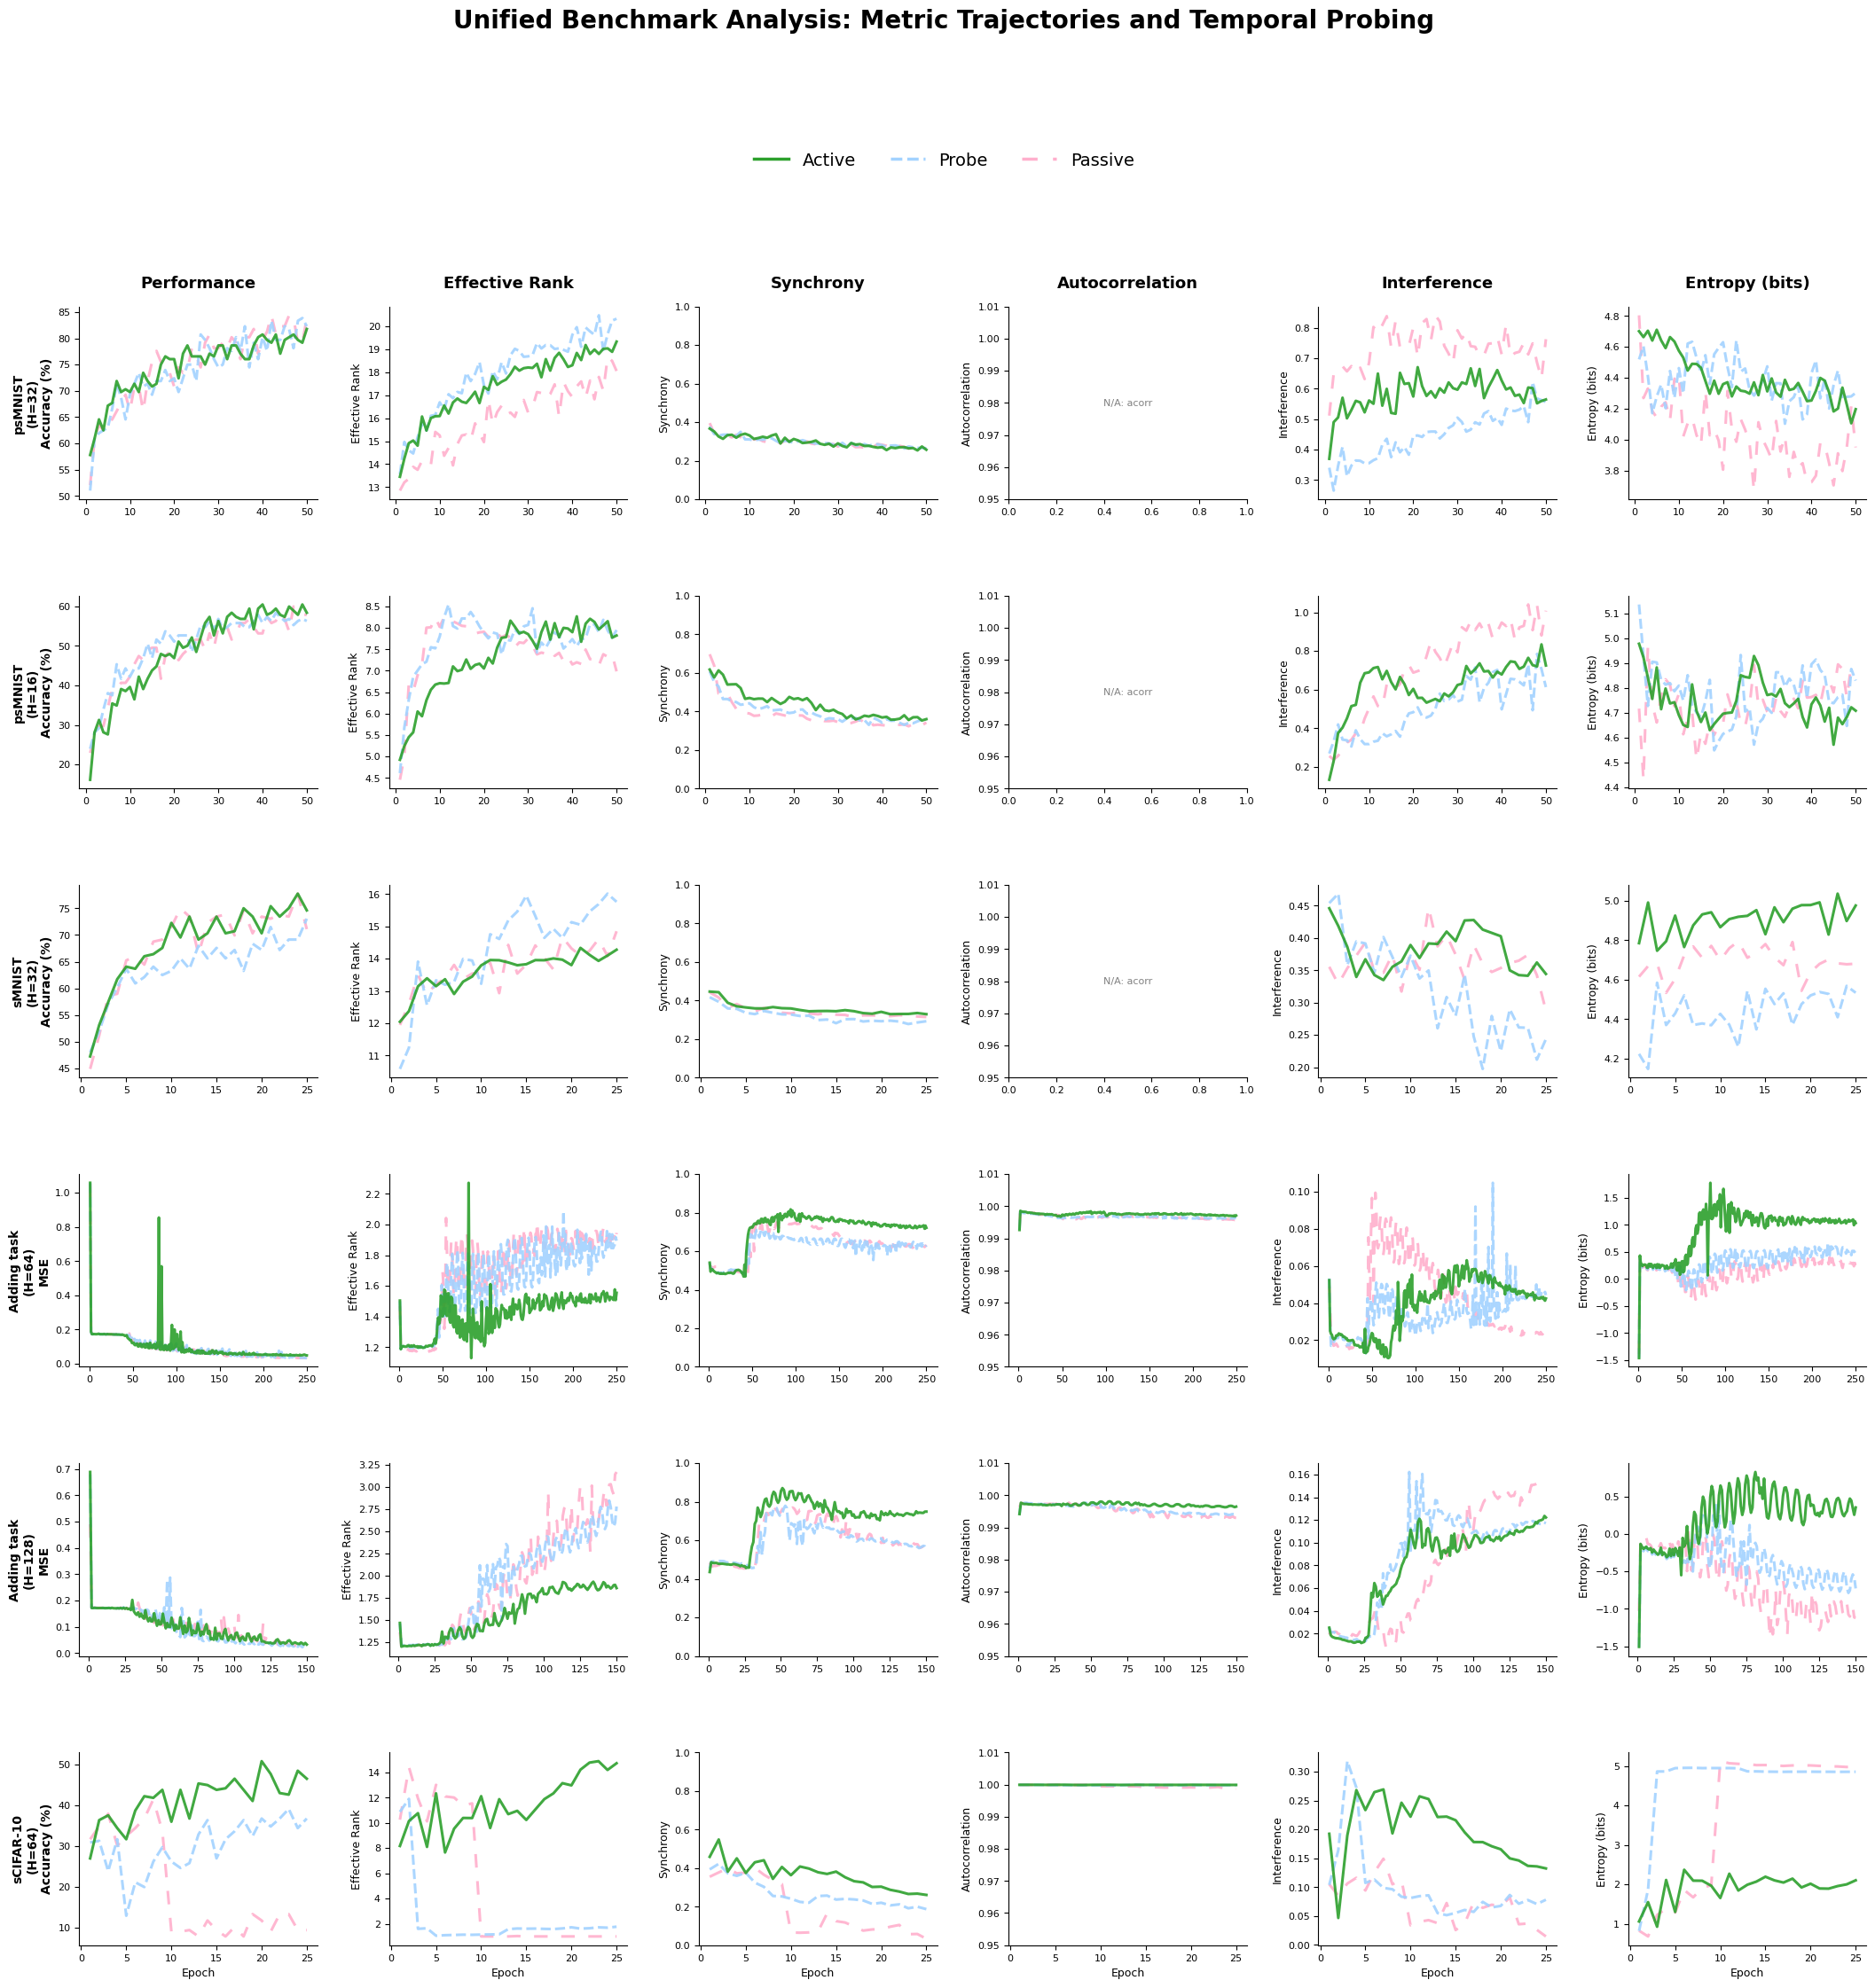

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import numpy as np

# --- 1. Configuration & Styling ---
CONDITIONS = ['Passive', 'Probe', 'Active']
COLORS = {
    'Active':  '#2ca02c',  # Green
    'Probe':   '#a2d2ff',  # Light Blue
    'Passive': '#ffafcc'   # Pink
}
LINESTYLES = {
    'Active':  '-',        # Solid
    'Probe':   '--',       # Small dashed
    'Passive': (0, (5, 5)) # Long dashed
}

# Format: (internal_key, display_label, ylim)
METRIC_PANELS = [
    ('val_metric',   'Performance',      None), 
    ('rank',         'Effective Rank',   None),
    ('sync',         'Synchrony',        (0.0, 1.0)), 
    ('acorr',        'Autocorrelation',  (0.95, 1.01)), # Zoomed range requested
    ('intf',         'Interference',     None),    
    ('entr',         'Entropy (bits)',   None),
]

# Ensure we only plot configs that have loaded data
active_configs = [k for k in CONFIGS.keys() if any(RESULTS.get(k, {}).values())]
n_rows, n_cols = len(active_configs), len(METRIC_PANELS)

# Widened figsize and adjusted top margin for the legend
fig, axes = plt.subplots(n_rows, n_cols, figsize=(26, 4.0 * n_rows))
fig.subplots_adjust(hspace=0.5, wspace=0.3, top=0.88) 

for row_i, cfg_key in enumerate(active_configs):
    cfg = CONFIGS[cfg_key]
    # Detect if we should label the first column as MSE (for Adding task) or Accuracy
    is_mse_bench = "Adding" in cfg_key or "mse" in str(cfg.get('benchmark', '')).lower()
    
    for col_i, (metric, label, ylim) in enumerate(METRIC_PANELS):
        # Handle indexing for single vs multiple benchmarks
        ax = axes[row_i, col_i] if n_rows > 1 else axes[col_i]
        plotted = False

        for cond in CONDITIONS:
            d = RESULTS[cfg_key].get(cond)
            # Normalization check: if 'acorr' isn't there, look for 'autocorrelation' etc.
            # (Handled by the extract_series function provided previously)
            if d is None or metric not in d:
                continue
            
            ax.plot(d['epochs'], d[metric],
                    color=COLORS[cond], 
                    ls=LINESTYLES[cond],
                    lw=2.2, 
                    alpha=0.9, 
                    label=cond)
            plotted = True

        if not plotted:
            ax.text(0.5, 0.5, f'N/A: {metric}', ha='center', va='center',
                    transform=ax.transAxes, fontsize=8, color='gray')

        # --- Labeling & Formatting ---
        display_label = label
        if metric == 'val_metric':
            display_label = "MSE" if is_mse_bench else "Accuracy (%)"

        # Row headers on the first column
        if col_i == 0:
            ax.set_ylabel(f"{cfg['benchmark']}\n(H={cfg['hidden']})\n{display_label}", 
                          fontsize=10, fontweight='bold')
        else:
            ax.set_ylabel(display_label, fontsize=9)

        # Column titles on the top row
        if row_i == 0:
            ax.set_title(label, fontsize=13, fontweight='bold', pad=15)

        if ylim: 
            ax.set_ylim(ylim)
        
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.tick_params(labelsize=8)
        if row_i == n_rows - 1:
            ax.set_xlabel('Epoch', fontsize=9)

# --- 2. Single Global Legend on Top ---
legend_elements = [
    Line2D([0], [0], color=COLORS['Active'],  ls=LINESTYLES['Active'],  lw=2.5, label='Active'),
    Line2D([0], [0], color=COLORS['Probe'],   ls=LINESTYLES['Probe'],   lw=2.5, label='Probe'),
    Line2D([0], [0], color=COLORS['Passive'], ls=LINESTYLES['Passive'], lw=2.5, label='Passive')
]

fig.legend(handles=legend_elements, 
           loc='upper center', 
           ncol=3,
           fontsize=14, 
           frameon=False, 
           bbox_to_anchor=(0.5, 0.96)) # Positioned above the plots

fig.suptitle('Unified Benchmark Analysis: Metric Trajectories and Temporal Probing', 
             fontsize=20, y=1.02, fontweight='bold')

plt.show()
# Save and Display



## Normalized

In [3]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import numpy as np

# --- 1. Configuration ---
n_rows, n_cols = len(active_configs), len(METRIC_PANELS)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(26, 4.5 * n_rows))
fig.subplots_adjust(hspace=0.5, wspace=0.3, top=0.88) 

for row_i, cfg_key in enumerate(active_configs):
    cfg = CONFIGS[cfg_key]
    is_mse_bench = "Adding" in cfg_key or "mse" in str(cfg.get('benchmark', '')).lower()
    
    for col_i, (metric, label, ylim) in enumerate(METRIC_PANELS):
        ax = axes[row_i, col_i] if n_rows > 1 else axes[col_i]
        
        # --- Normalization Logic ---
        # First, find the global max for this metric across all conditions in this row
        all_series = []
        for cond in CONDITIONS:
            d = RESULTS[cfg_key].get(cond)
            if d is not None and metric in d:
                all_series.append(np.array(d[metric]))
        
        if len(all_series) > 0:
            # We normalize by the absolute maximum observed in any condition for this config
            global_max = np.max([np.max(np.abs(s)) for s in all_series])
            if global_max == 0: global_max = 1.0
        else:
            global_max = 1.0

        plotted = False
        for cond in CONDITIONS:
            d = RESULTS[cfg_key].get(cond)
            if d is None or metric not in d:
                continue
            
            # Apply Normalization
            norm_data = np.array(d[metric]) / global_max
            
            ax.plot(d['epochs'], norm_data,
                    color=COLORS[cond], 
                    ls=LINESTYLES[cond],
                    lw=2.5, 
                    alpha=0.9)
            plotted = True

        # --- Formatting ---
        if col_i == 0:
            row_title = f"{cfg['benchmark']}\n(H={cfg['hidden']})"
            ax.set_ylabel(f"{row_title}\nRel. {label}", fontsize=10, fontweight='bold')
        else:
            ax.set_ylabel(f"Rel. {label}", fontsize=9)

        if row_i == 0:
            ax.set_title(label, fontsize=14, fontweight='bold', pad=20)

        # Since it's normalized, we fix the Y-limit to [0, 1.1] unless specified
        # (Autocorr zooming is usually better left un-normalized, but here we scale it)
        if metric == 'acorr':
            ax.set_ylim(0.995, 1.01) # Keep the focus on the high-correlation regime
        else:
            ax.set_ylim(-0.4, 1.1)
        
        ax.spines[['top', 'right']].set_visible(False)
        if row_i == n_rows - 1:
            ax.set_xlabel('Epoch', fontsize=10)

# --- 2. Global Legend ---
legend_elements = [Line2D([0], [0], color=COLORS[c], ls=LINESTYLES[c], lw=3, label=c) for c in CONDITIONS]
fig.legend(handles=legend_elements, loc='upper center', ncol=3, fontsize=15, 
           frameon=False, bbox_to_anchor=(0.5, 0.95))

fig.suptitle('Normalized Temporal Dynamics: Scaled Trajectories across Benchmarks', 
             fontsize=22, y=1.0, fontweight='bold')

plt.show()

NameError: name 'active_configs' is not defined

## 4. Figure Final-Epoch Summary: Bar Chart + Test Accuracy

Successfully saved high-res figure as final_metric_comparison_grid.png


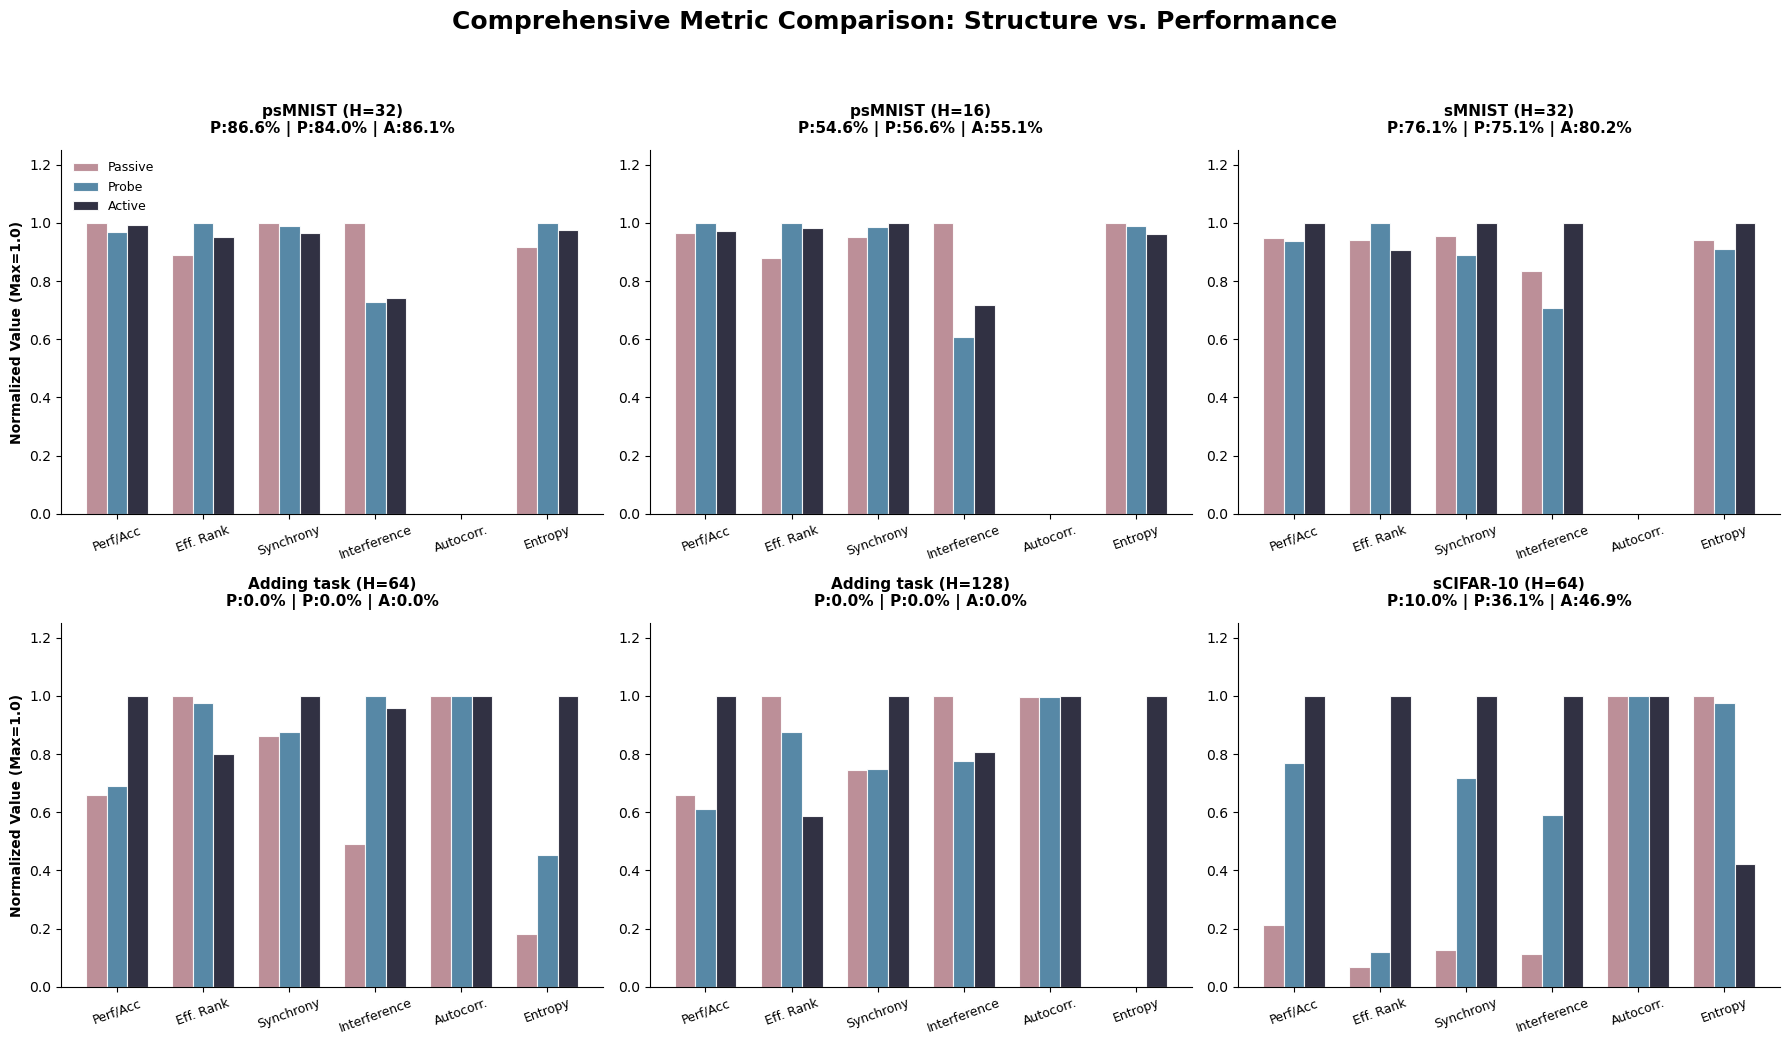

In [4]:
import matplotlib.pyplot as plt
import numpy as np
# Mapping to handle inconsistent naming across different benchmark runs
KEY_MAP = {
    'effective_rank':  'rank',
    'synchrony':       'sync',
    'interference':    'intf',
    'entropy':         'entr',
    'autocorrelation': 'acorr',
    'a_corr':          'acorr',
    'accuracy':        'perf',
    'acc':             'perf',
    'mse':             'perf'
}
# --- 1. Metric Definition ---
BAR_METRICS = [
    ('perf',  'Perf/Acc'),
    ('rank',  'Eff. Rank'),
    ('sync',  'Synchrony'),
    ('intf',  'Interference'),
    ('acorr', 'Autocorr.'),
    ('entr',  'Entropy'),
]
import matplotlib.pyplot as plt
import numpy as np
import os

# --- Grid Setup ---
rows, cols = 2, 3
fig, axes = plt.subplots(rows, cols, figsize=(18, 10), facecolor='white')
axes_flat = axes.flatten()

active_configs = [k for k in CONFIGS.keys() if any(RESULTS.get(k, {}).values())]
x = np.arange(len(BAR_METRICS))
width = 0.24
offsets = {'Passive': -width, 'Probe': 0, 'Active': width}

for i in range(rows * cols):
    ax = axes_flat[i]
    if i >= len(active_configs):
        ax.axis('off')
        continue
        
    cfg_key = active_configs[i]
    cfg = CONFIGS[cfg_key]
    bench_name = str(cfg.get('benchmark', '')).lower()
    is_mse = "adding" in bench_name or "mse" in bench_name
    is_spatial_acorr = "smnist" in bench_name or "psmnist" in bench_name

    # 1. Extraction
    raw_vals_by_cond = {}
    for cond in CONDITIONS:
        d = RESULTS[cfg_key].get(cond)
        if d is None: continue
        
        # KEY_MAP is now defined above
        extracted = {KEY_MAP.get(k, k): v[-1] for k, v in d.items() if isinstance(v, (list, np.ndarray))}
        
        if 'test_acc' in d:
            extracted['perf'] = d['test_acc']
        raw_vals_by_cond[cond] = extracted

    # 2. Per-Metric Global Max
    max_vals = {m: max([raw_vals_by_cond[c].get(m, 0.0) for c in raw_vals_by_cond] or [1.0]) for m, _ in BAR_METRICS}

    # 3. Plotting Bars
    for cond in CONDITIONS:
        if cond not in raw_vals_by_cond: continue
        norm_vals = []
        for m, _ in BAR_METRICS:
            val = 0.0 if (m == 'acorr' and is_spatial_acorr) else raw_vals_by_cond[cond].get(m, 0.0)
            divisor = max_vals[m] if max_vals[m] != 0 else 1.0
            norm_vals.append(val / divisor)

        ax.bar(x + offsets[cond], norm_vals, width, label=cond, 
               color=COLORS[cond], edgecolor='white', lw=0.8, alpha=0.9)

    # 4. Styling
    perf_labels = [f"{c[0]}:{RESULTS[cfg_key][c]['test_acc']:.1f}%" for c in CONDITIONS if c in RESULTS[cfg_key]]
    ax.set_title(f"{cfg['benchmark']} (H={cfg['hidden']})\n" + " | ".join(perf_labels),
                 fontsize=11, fontweight='bold', pad=12)

    ax.set_xticks(x)
    ax.set_xticklabels([lbl for _, lbl in BAR_METRICS], fontsize=9, rotation=20)
    ax.set_ylim(0, 1.25)
    
    if i % cols == 0: 
        ax.set_ylabel('Normalized Value (Max=1.0)', fontsize=10, fontweight='bold')
    if i == 0: 
        ax.legend(fontsize=9, frameon=False, loc='upper left')
    
    ax.spines[['top', 'right']].set_visible(False)

fig.suptitle('Comprehensive Metric Comparison: Structure vs. Performance', 
             fontsize=18, y=1.04, fontweight='bold')

plt.tight_layout()

# --- Copiable Export ---
# PDF is vector-based; PNG is 300 DPI for high-quality copy-paste
output_name = 'final_metric_comparison_grid.png'
plt.savefig(output_name, bbox_inches='tight', dpi=300, facecolor='white')
print(f"Successfully saved high-res figure as {output_name}")

plt.show()

## 5. Figure Coordination-Without-Collapse Scatter
Synchrony vs Interference across training epochs. Ideal trajectory: high sync, low interference.

  Saved: /home/casper/Documents/A_Casper/Brein/CS_Ai_Wolfhampton/Dissertation/figures/fig_sync_intf_scatter_evolution.pdf


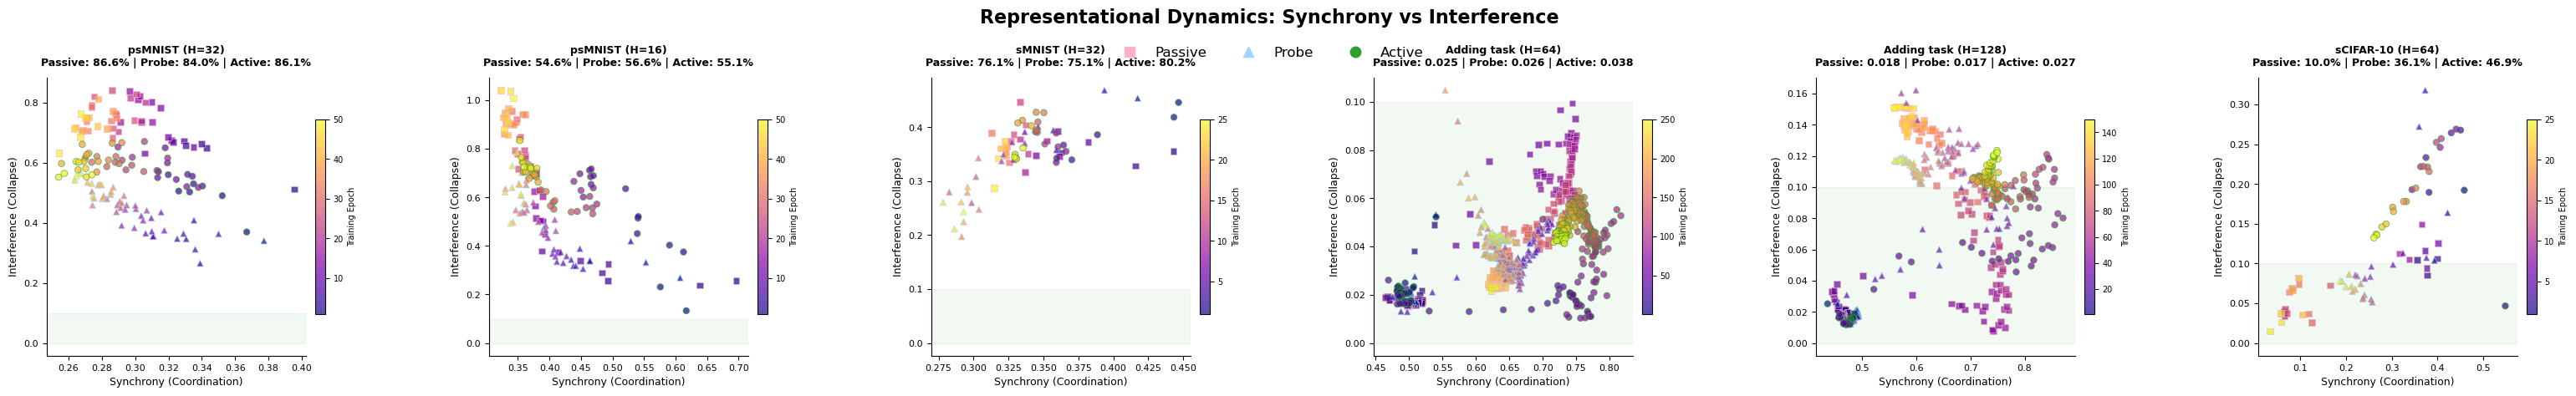

In [5]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D

# --- 1. Configuration & Styling ---
COLORS = {'Active': '#2ca02c', 'Probe': '#a2d2ff', 'Passive': '#ffafcc'}
MARKERS = {'Active': 'o', 'Probe': '^', 'Passive': 's'}
CONDITIONS = ['Passive', 'Probe', 'Active']

# Consistent mapping for your benchmark JSONs
KEY_MAP = {
    'synchrony': 'sync', 
    'interference': 'intf'
}

active_configs = [k for k in CONFIGS.keys() if any(RESULTS.get(k, {}).values())]
n_benchmarks = len(active_configs)

# Adjust layout to fit legend under the title
fig, axes = plt.subplots(1, n_benchmarks, figsize=(6.5 * n_benchmarks, 5.2), squeeze=False)
fig.subplots_adjust(wspace=0.4, bottom=0.18, top=0.82)

for i, cfg_key in enumerate(active_configs):
    ax = axes[0, i]
    cfg = CONFIGS[cfg_key]
    bench_name = str(cfg.get('benchmark', '')).lower()
    is_mse = "adding" in bench_name or "mse" in bench_name
    
    last_sc = None # Track for colorbar

    for cond in CONDITIONS:
        d = RESULTS[cfg_key].get(cond)
        if d is None: continue
        
        # Extract trajectories using mapping
        # Looks for 'sync' then 'synchrony'; 'intf' then 'interference'
        y_sync = d.get('sync', d.get('synchrony'))
        x_intf = d.get('intf', d.get('interference'))
        epochs = d.get('epochs', np.arange(len(y_sync)))

        if y_sync is None or x_intf is None:
            continue

        sc = ax.scatter(
            y_sync, x_intf,
            c=epochs, 
            cmap='plasma', 
            vmin=1, vmax=epochs[-1],
            s=30, 
            alpha=0.7,
            marker=MARKERS[cond], 
            edgecolors=COLORS[cond], 
            linewidths=0.6,
            label=cond
        )
        last_sc = sc

    # 2. Quadrant Shading (Target Area)
    # Highlight area of Low Interference and High Synchrony (Good Coordination)
    ax.axhspan(0, 0.1, alpha=0.05, color='green', label='Low Intf Zone')
    
    # 3. Titles & Labels
    perf_summaries = []
    for cond in CONDITIONS:
        d = RESULTS[cfg_key].get(cond)
        if d and 'test_acc' in d:
            val = d['test_acc']
            perf_summaries.append(f"{cond}: {val:.3f}" if is_mse else f"{cond}: {val:.1f}%")
    
    ax.set_title(f"{cfg['benchmark']} (H={cfg['hidden']})\n" + " | ".join(perf_summaries),
                 fontsize=9, fontweight='bold', pad=10)
    
    ax.set_xlabel('Synchrony (Coordination)', fontsize=9)
    ax.set_ylabel('Interference (Collapse)', fontsize=9)
    
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(labelsize=8)

    # 4. Colorbar per subplot for Epochs
    if last_sc:
        cbar = fig.colorbar(last_sc, ax=ax, pad=0.03, shrink=0.7)
        cbar.set_label('Training Epoch', fontsize=7)
        cbar.ax.tick_params(labelsize=7)

# --- 5. Global Title and Legend ---
fig.suptitle('Representational Dynamics: Synchrony vs Interference', 
             fontsize=16, y=0.98, fontweight='bold')

# Legend placed under title
legend_elements = [
    Line2D([0], [0], marker=MARKERS[c], color='w', label=c,
           markerfacecolor=COLORS[c], markeredgecolor=COLORS[c], markersize=9)
    for c in CONDITIONS
]
fig.legend(handles=legend_elements, loc='upper center', ncol=3, 
           fontsize=12, frameon=False, bbox_to_anchor=(0.5, 0.92))

savefig(fig, 'fig_sync_intf_scatter_evolution')
plt.show()

In [8]:
# --- 0. Backend + PDF safety (MUST come first) ---
import matplotlib as mpl
mpl.use("pdf")

mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42
mpl.rcParams['font.family'] = 'serif'
mpl.rcParams['axes.unicode_minus'] = False
mpl.rcParams['pdf.compression'] = 6

# --- Imports ---
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from scipy.ndimage import gaussian_filter1d
import matplotlib.patches as patches
from matplotlib.lines import Line2D
from pathlib import Path

# --- 1. Configuration ---
END_MARKERS = {'Active': 'D', 'Passive': 'o', 'Probe': 's'}
COLORS = {'Active': '#2ca02c', 'Probe': '#a2d2ff', 'Passive': '#ffafcc'}
LINE_STYLES = {'Active': '-', 'Passive': '--', 'Probe': ':'}
CONDITIONS = ['Passive', 'Probe', 'Active']
SMOOTH_SIGMA = 2
GLOBAL_ALPHA = 0.9

# --- Output path ---
OUT_DIR = Path("/home/casper/BUBU_FIGS/")
OUT_DIR.mkdir(parents=True, exist_ok=True)
OUT_PATH = OUT_DIR / "fig_coordination_trajectories_2x3_grid.pdf"

# --- Active configs ---
active_configs = [k for k in CONFIGS.keys() if any(RESULTS.get(k, {}).values())]
n_configs = len(active_configs)

# --- 2. Figure setup ---
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.subplots_adjust(wspace=0.3, hspace=0.35, bottom=0.12, top=0.85)

# --- 3. Plot loop ---
for i in range(6):
    row, col = divmod(i, 3)
    ax = axes[row, col]

    if i >= n_configs:
        ax.set_visible(False)
        continue

    cfg_key = active_configs[i]
    cfg = CONFIGS[cfg_key]
    sc_ref = None

    for cond in CONDITIONS:
        d = RESULTS[cfg_key].get(cond)
        if d is None:
            continue

        raw_x = d.get('sync', d.get('synchrony'))
        raw_y = d.get('intf', d.get('interference'))

        if raw_x is None or raw_y is None:
            continue

        epochs = d.get('epochs', np.arange(len(raw_x)))

        # --- Smoothing ---
        s_x = gaussian_filter1d(raw_x, sigma=SMOOTH_SIGMA)
        s_y = gaussian_filter1d(raw_y, sigma=SMOOTH_SIGMA)

        # --- Gradient trajectory ---
        points = np.array([s_x, s_y]).T.reshape(-1, 1, 2)
        segments = np.concatenate([points[:-1], points[1:]], axis=1)

        norm = plt.Normalize(1, epochs[-1])
        lc = LineCollection(
            segments,
            cmap='plasma',
            norm=norm,
            alpha=GLOBAL_ALPHA,
            lw=2.5,
            linestyles=LINE_STYLES[cond],
            zorder=3
        )
        lc.set_array(epochs)
        sc_ref = ax.add_collection(lc)

        # --- Anchors ---
        ax.scatter(
            s_x[0], s_y[0],
            marker='o', s=40,
            facecolors='none',
            edgecolors=COLORS[cond],
            linewidths=1.2,
            alpha=0.5,
            zorder=4
        )

        ax.scatter(
            s_x[-1], s_y[-1],
            marker=END_MARKERS[cond],
            s=80,
            color=COLORS[cond],
            edgecolors='white',
            linewidths=1,
            zorder=5
        )

    # --- Zones ---
    ax.axhspan(0.7, 1.0, color='#e74c3c', alpha=0.05, zorder=0)

    ax.text(
        0.5, 0.85, 'PATHOLOGICAL ENTRAINMENT',
        fontsize=8, color='#c0392b',
        fontweight='bold', alpha=0.5,
        ha='center'
    )

    success_zone = patches.Rectangle(
        (0.4, 0.0), 0.6, 0.45,
        color='#2ecc71',
        alpha=0.05,
        zorder=0
    )
    ax.add_patch(success_zone)

    ax.text(
        0.7, 0.15,
        'COORDINATION\nWITHOUT COLLAPSE',
        fontsize=8,
        color='#27ae60',
        fontweight='bold',
        alpha=0.6,
        ha='center'
    )

    # --- Axes formatting ---
    ax.set_title(f'{cfg["benchmark"]} (H={cfg["hidden"]})', fontsize=11, fontweight='bold')
    ax.set_xlabel('Synchrony', fontsize=9)
    ax.set_ylabel('Interference', fontsize=9)

    ax.set_xlim(0, 1.0)
    ax.set_ylim(0, 1.0)

    ax.grid(True, linestyle=':', alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    if sc_ref:
        cbar = fig.colorbar(sc_ref, ax=ax, pad=0.03, shrink=0.6)
        cbar.set_label('Epoch', fontsize=7)

# --- 4. Title + Legend ---
fig.suptitle(
    'Geometric Analysis of Coordination Trajectories\n$2 \\times 3$ Comparative Benchmark Grid',
    fontsize=18,
    y=0.96,
    fontweight='bold'
)

legend_elements = [
    Line2D([0], [0],
           marker=END_MARKERS[c],
           color='w',
           label=f"{c} Condition",
           markerfacecolor=COLORS[c],
           markeredgecolor='black',
           markersize=10)
    for c in CONDITIONS
]

legend_elements.append(
    Line2D([0], [0],
           marker='o',
           color='w',
           label="Initialization",
           markerfacecolor='none',
           markeredgecolor='gray',
           markersize=8)
)

fig.legend(
    handles=legend_elements,
    loc='upper center',
    ncol=4,
    fontsize=12,
    frameon=False,
    bbox_to_anchor=(0.5, 0.90)
)

# --- 5. Save ---
fig.savefig(
    OUT_PATH,
    format="pdf",
    bbox_inches="tight",
    dpi=300,
    metadata={
        "Title": "Geometric Analysis of Coordination Trajectories",
        "Author": "Casper",
        "Subject": "Global Field Mechanism",
    }
)

plt.close(fig)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from scipy.ndimage import gaussian_filter1d
import matplotlib.patches as patches
from matplotlib.lines import Line2D
from pathlib import Path

# --- Global Style Configuration ---
BASE_SIZE = 14 
plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Liberation Serif'],
    'font.size': BASE_SIZE,
    'axes.titlesize': BASE_SIZE * 1.1,
    'axes.labelsize': BASE_SIZE,
    'xtick.labelsize': BASE_SIZE * 0.8,
    'ytick.labelsize': BASE_SIZE * 0.8,
    'legend.fontsize': BASE_SIZE * 0.9,
    'pdf.fonttype': 42
})

END_MARKERS = {'Active': 'D', 'Probe': 's', 'Passive': 'o'}
C_MAP = {'Active': '#2ca02c', 'Probe': '#a2d2ff', 'Passive': '#ffafcc'}
LS_MAP = {'Active': '-', 'Probe': '--', 'Passive': (0, (5, 5))}
CONDITIONS = ['Passive', 'Probe', 'Active']
SMOOTH_SIGMA = 2

OUT_DIR = Path("/home/casper/BUBU_FIGS/")
OUT_DIR.mkdir(parents=True, exist_ok=True)
OUT_PATH = OUT_DIR / "fig3.pdf"

active_keys = [k for k in RESULTS.keys() if any(RESULTS[k].values())]

n_rows, n_cols = 2, 3
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 12))
axes_flat = axes.flatten()

for i, cfg_key in enumerate(active_keys):
    if i >= len(axes_flat): break
    ax = axes_flat[i]
    is_mse = "Adding" in cfg_key or "adding" in cfg_key
    
    # 1. Determine X-axis Scale
    if is_mse:
        max_rank = 5
    else:
        active_res = RESULTS[cfg_key].get('Active')
        max_rank = active_res['config'].get('hidden', 32) if (active_res and 'config' in active_res) else 32

    # 2. Plot Lines
    last_lc = None
    for cond in CONDITIONS:
        d = RESULTS[cfg_key].get(cond)
        if d is None or d.get('rank') is None: continue
        
        x_raw, y_raw, eps = d['rank'], d['val_metric'], d['epochs']
        s_x = gaussian_filter1d(x_raw, sigma=SMOOTH_SIGMA)
        s_y = gaussian_filter1d(y_raw, sigma=SMOOTH_SIGMA)
        
        # Ensure y stays above 0 for log scaling
        if is_mse: s_y = np.maximum(s_y, 1e-5)

        points = np.array([s_x, s_y]).T.reshape(-1, 1, 2)
        segments = np.concatenate([points[:-1], points[1:]], axis=1)
        
        lc = LineCollection(segments, cmap='plasma', norm=plt.Normalize(eps[0], eps[-1]), 
                            alpha=0.8, lw=2.5, linestyles=LS_MAP[cond], zorder=3)
        lc.set_array(eps)
        ax.add_collection(lc)
        last_lc = lc # Keep for colorbar reference
        
        ax.scatter(s_x[-1], s_y[-1], marker=END_MARKERS[cond], s=80, 
                   color=C_MAP[cond], edgecolors='white', lw=1, zorder=5)

    # 3. Add Individual Heatmap Bar (Epochs)
    if last_lc:
        cbar = fig.colorbar(last_lc, ax=ax, fraction=0.046, pad=0.04)
        cbar.ax.set_ylabel('Epochs', rotation=270, labelpad=15, fontsize=BASE_SIZE*0.7)
        cbar.ax.tick_params(labelsize=BASE_SIZE*0.6)

    # 4. Axis Scaling & Interpretation Zones
    zone_text_size = BASE_SIZE * 0.6
    
    if is_mse:
        # Logarithmic MSE Scaling: 0.4 at bottom, ~0 at top
        ax.set_yscale('log')
        y_bottom, y_top = 0.4, 1e-4  # Log cannot be 0, using 1e-4 as "solved"
        
        # Collapse Zone (High MSE)
        ax.add_patch(patches.Rectangle((0, 0.1), max_rank*0.4, 0.3, color='#95a5a6', alpha=0.1, zorder=0))
        ax.text(max_rank*0.2, 0.2, 'REPRESENTATIONAL\nCOLLAPSE', 
                fontsize=zone_text_size, color='#7f8c8d', ha='center', fontweight='bold')

        # Specialization Zone (Low MSE)
        ax.add_patch(patches.Rectangle((max_rank*0.7, 1e-4), max_rank*0.3, 0.001, color='#3498db', alpha=0.08, zorder=0))
        ax.text(max_rank*0.85, 5e-4, 'HIGH-RANK\nSPECIALIZATION', 
                fontsize=zone_text_size, color='#2980b9', ha='center', fontweight='bold')
        
        ax.set_ylim(y_bottom, y_top) 
        ax.set_ylabel('MSE (Log Scale)')
    else:
        # Linear Accuracy Scaling
        ax.set_ylim(0, 105)
        ax.add_patch(patches.Rectangle((0, 0), max_rank*0.4, 40, color='#95a5a6', alpha=0.1, zorder=0))
        ax.text(max_rank*0.2, 20, 'REPRESENTATIONAL\nCOLLAPSE', fontsize=zone_text_size, color='#7f8c8d', ha='center', fontweight='bold')
        
        ax.add_patch(patches.Rectangle((max_rank*0.7, 70), max_rank*0.3, 30, color='#3498db', alpha=0.08, zorder=0))
        ax.text(max_rank*0.85, 85, 'HIGH-RANK\nSPECIALIZATION', fontsize=zone_text_size, color='#2980b9', ha='center', fontweight='bold')
        ax.set_ylabel('Accuracy (%)')

    ax.set_xlim(0, max_rank)
    ax.set_xlabel('Effective Rank')
    ax.set_title(f'{cfg_key}', fontweight='bold')
    ax.grid(True, which='both', linestyle=':', alpha=0.3)

# Cleanup
for j in range(i + 1, len(axes_flat)):
    axes_flat[j].axis('off')

# Legend: Line Style + Marker Shape
legend_elements = [
    Line2D([0], [0], linestyle=LS_MAP[c], color=C_MAP[c], 
           marker=END_MARKERS[c], markerfacecolor=C_MAP[c], 
           markeredgecolor='white', markersize=10, lw=2, label=c) for c in CONDITIONS
]
fig.legend(handles=legend_elements, loc='lower center', ncol=3, bbox_to_anchor=(0.5, 0.02), frameon=False)

plt.tight_layout(rect=[0, 0.08, 1, 0.98])
plt.savefig(OUT_PATH, bbox_inches='tight', dpi=300)
plt.show()

/tmp/ipykernel_87928/1123068093.py:131: UserWarning: FigureCanvasPdf is non-interactive, and thus cannot be shown
  plt.show()


In [13]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from scipy.ndimage import gaussian_filter1d
import matplotlib.patches as patches
from matplotlib.lines import Line2D
 # --- 1. Configuration ---

END_MARKERS = {'Active': 'D', 'Passive': 'o', 'Probe': 's'}

COLORS = {'Active': '#2ca02c', 'Probe': '#a2d2ff', 'Passive': '#ffafcc'}

LINE_STYLES = {'Active': '-', 'Passive': '--', 'Probe': ':'}

CONDITIONS = ['Passive', 'Probe', 'Active']

SMOOTH_SIGMA = 2

GLOBAL_ALPHA = 0.9


# --- Output path ---

OUT_DIR = Path("/home/casper/BUBU_FIGS/")

OUT_DIR.mkdir(parents=True, exist_ok=True)

OUT_PATH = OUT_DIR / "fig3.pdf" 

# --- 1. DYNAMIC CONFIGURATION HUB ---
# Define specific settings per benchmark. 'default' is used if key isn't found.
PLOT_CONFIG = {
    'CIFAR10': {
        'x_lim': (0.99, 1.0),      # Wider X for CIFAR to see the approach
        'y_lim': (0, 10),          # Higher entropy ceiling for CIFAR
        'frozen_zone': 0.99,
        'stability_center': (0.97, 4.0),
        'stability_size': (0.02, 2.0)
    },
    'default': {
        'x_lim': (0.98, 1.0),
        'y_lim': (0, 2),           # Tighter for Adding
        'frozen_zone': 0.996,
        'stability_center': (0.99, 0.4),
        'stability_size': (0.008, 0.5)
    }
}

SMOOTH_SIGMA = 1.2 
COLORS = {'Active': '#2ca02c', 'Probe': '#a2d2ff', 'Passive': '#ffafcc'}
END_MARKERS = {'Active': 'D', 'Probe': 's', 'Passive': 'o'}
LINE_STYLES = {'Active': 'solid', 'Probe': '--', 'Passive': (0, (5, 5))}
CONDITIONS = ['Passive', 'Probe', 'Active']

def get_metric(d, keys):
    for k in keys:
        if k in d and d[k] is not None: return d[k]
    return None

# --- 2. Plotting Logic ---
cfg_keys = [k for k in RESULTS.keys() if any(x in k.lower() for x in ['adding', 'cifar'])]
fig, axes = plt.subplots(1, len(cfg_keys), figsize=(7 * len(cfg_keys), 6))
if len(cfg_keys) == 1: axes = [axes]

for ax, cfg_key in zip(axes, cfg_keys):
    # Select config based on key, fallback to default
    conf = PLOT_CONFIG.get(cfg_key, PLOT_CONFIG['default'])
    
    for cond in CONDITIONS:
        d = RESULTS[cfg_key].get(cond)
        if d is None: continue
        
        x_raw = get_metric(d, ['acorr', 'a_corr'])
        y_raw = get_metric(d, ['entr', 'entropy'])
        epochs = d.get('epochs')
        
        if x_raw is None or y_raw is None: continue

        s_x = gaussian_filter1d(x_raw, sigma=SMOOTH_SIGMA)
        s_y = gaussian_filter1d(y_raw, sigma=SMOOTH_SIGMA)
        
        step = 8 if cond != 'Active' else 1
        s_x_sub, s_y_sub = s_x[::step], s_y[::step]
        e_sub = np.array(epochs)[::step]
        
        pts = np.array([s_x_sub, s_y_sub]).T.reshape(-1, 1, 2)
        segments = np.concatenate([pts[:-1], pts[1:]], axis=1)

        if len(segments) > 0:
            lc = LineCollection(segments, cmap='plasma', 
                                norm=plt.Normalize(min(epochs), max(epochs)), 
                                alpha=0.85, lw=3.5, 
                                linestyles=LINE_STYLES[cond], zorder=3)
            lc.set_array(e_sub[:-1]) 
            ax.add_collection(lc)
        
        ax.scatter(s_x[-1], s_y[-1], marker=END_MARKERS[cond], s=120, 
                   color=COLORS[cond], edgecolors='white', lw=1.5, zorder=5)

    # --- Apply Per-Subplot Settings ---
    ax.set_xlim(*conf['x_lim'])
    ax.set_ylim(*conf['y_lim']) 
    
    # Dynamic Zone Overlays
    fz_start = conf['frozen_zone']
    ax.axvspan(fz_start, 1.0, color='#34495e', alpha=0.1, zorder=0)
    ax.text(fz_start + (1-fz_start)/2, conf['y_lim'][1]*0.85, 'FROZEN', 
            fontsize=8, color='#2c3e50', ha='center', fontweight='bold', rotation=90)
    
    st_x, st_y = conf['stability_center']
    st_w, st_h = conf['stability_size']
    ax.add_patch(patches.Ellipse((st_x, st_y), st_w, st_h, color='#9b59b6', alpha=0.08, zorder=0))
    ax.text(st_x, st_y, 'DYNAMIC\nSTABILITY', fontsize=8, color='#8e44ad', ha='center', fontweight='bold')

    ax.set_xlabel('Auto-correlation', fontweight='bold')
    ax.set_ylabel('State Entropy (Bits)', fontweight='bold')
    ax.set_title(f'Phase Space: {cfg_key}', fontsize=14, fontweight='bold', pad=20)
    ax.grid(True, linestyle=':', alpha=0.4)

# Global Legend
legend_elements = [Line2D([0], [0], color=COLORS[c], ls=LINE_STYLES[c], label=c,
                          marker=END_MARKERS[c], markersize=10, markeredgecolor='white') 
                   for c in CONDITIONS]
fig.legend(handles=legend_elements, loc='lower center', ncol=3, bbox_to_anchor=(0.5, -0.05), frameon=False)

plt.tight_layout()
# --- Save to PDF ---
plt.savefig(OUT_PATH, bbox_inches='tight', dpi=300)
print(f"Figure saved to: {OUT_PATH}")

# Show the plot
plt.show()
plt.show()

/tmp/ipykernel_48732/304613228.py:126: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  plt.tight_layout()


Figure saved to: /home/casper/BUBU_FIGS/fig3.pdf


/tmp/ipykernel_48732/304613228.py:132: UserWarning: FigureCanvasPdf is non-interactive, and thus cannot be shown
  plt.show()
/tmp/ipykernel_48732/304613228.py:133: UserWarning: FigureCanvasPdf is non-interactive, and thus cannot be shown
  plt.show()


/tmp/ipykernel_61011/1509770377.py:112: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.05, 0.92, 0.98])


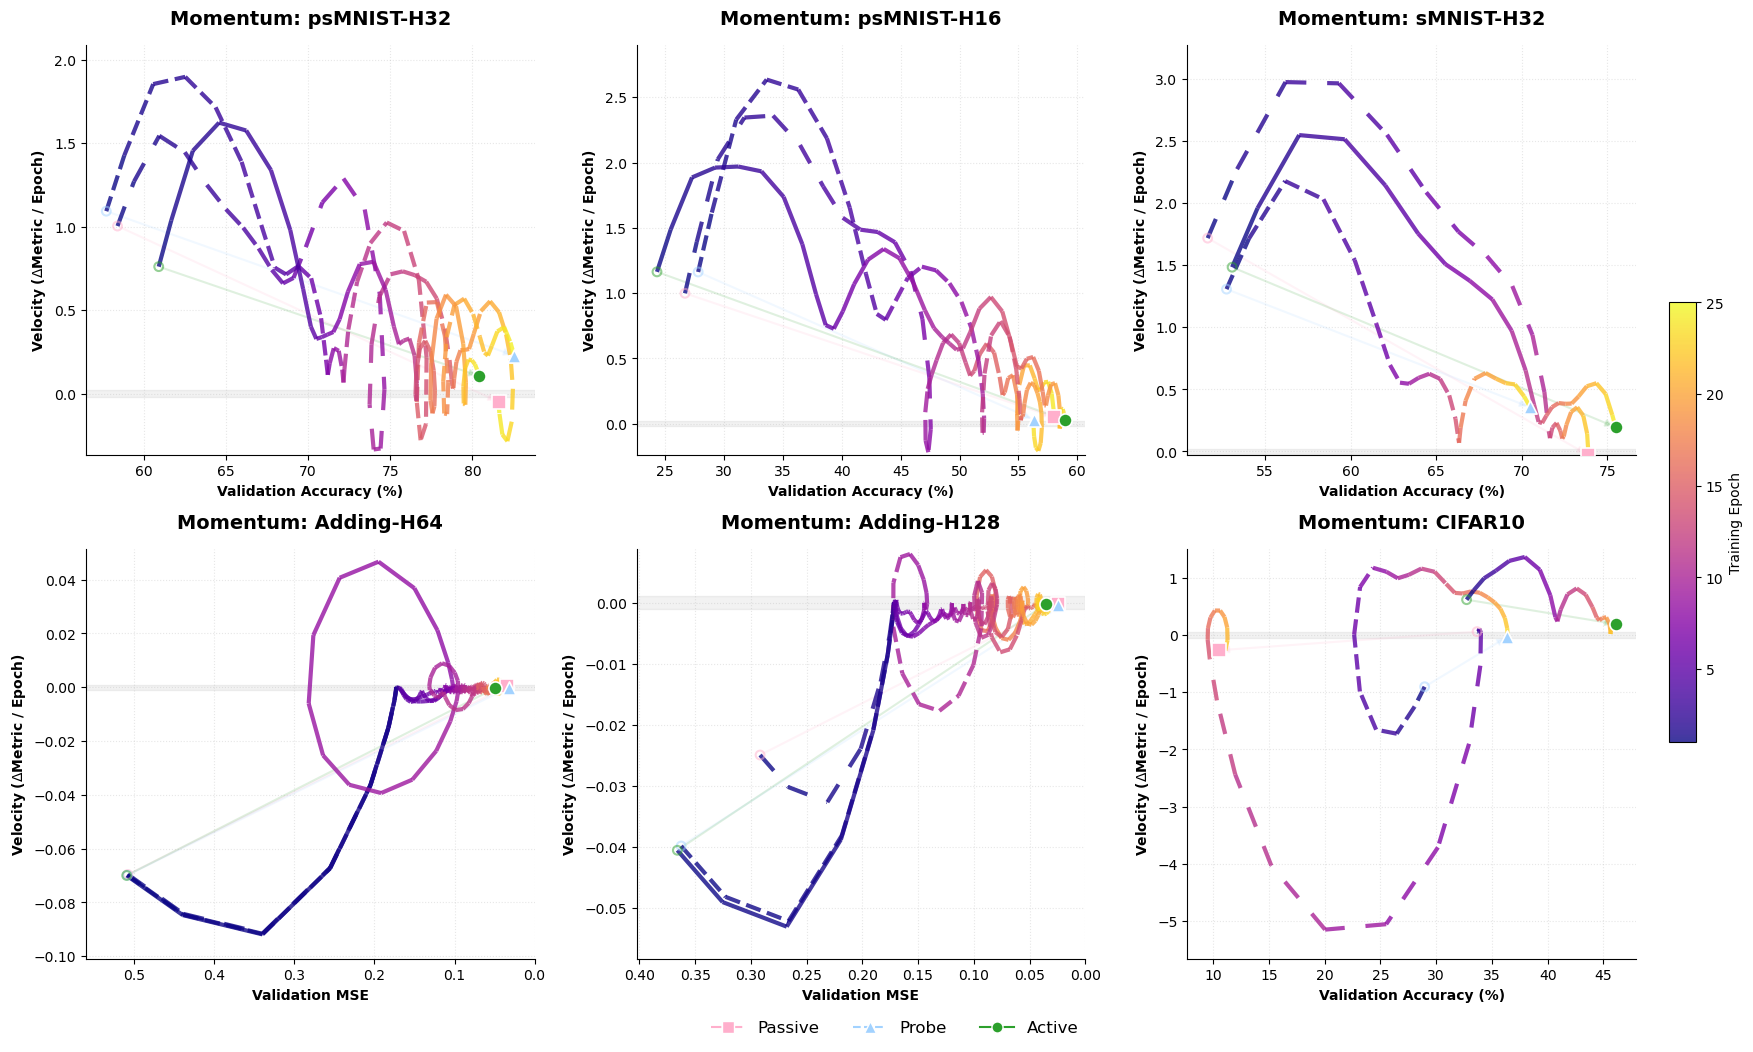

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from scipy.ndimage import gaussian_filter1d
from matplotlib.lines import Line2D

# --- 1. DYNAMIC MOMENTUM CONFIGURATION ---
MOMENTUM_CONFIG = {
    'CIFAR':  {'conv_thresh': 0.05, 'is_mse': False},
    'Adding': {'conv_thresh': 0.001, 'is_mse': True},
    'MNIST':  {'conv_thresh': 0.02, 'is_mse': False},
    'default':{'conv_thresh': 0.02, 'is_mse': False}
}

def get_mom_conf(name):
    for key in MOMENTUM_CONFIG:
        if key.lower() in name.lower(): return MOMENTUM_CONFIG[key]
    return MOMENTUM_CONFIG['default']

# --- 2. SETUP 2x3 GRID ---
all_keys = list(CONFIGS.keys())
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
axes_flat = axes.flatten()

SMOOTH_SIGMA = 2.0

for i, cfg_key in enumerate(all_keys):
    ax = axes_flat[i]
    m_conf = get_mom_conf(cfg_key)
    sc = None 
    
    # Track extremes for dynamic Y-scaling
    current_benchmark_velocities = []
    current_benchmark_metrics = []
    
    # First pass: Gather data for scaling
    stored_data = []
    
    for cond in CONDITIONS:
        d = RESULTS[cfg_key].get(cond)
        if d is None: continue
            
        raw_val = d.get('val_metric')
        epochs = d.get('epochs')
        if raw_val is None or epochs is None: continue
        
        # 1. Smooth & Calculate Velocity
        val_smooth = gaussian_filter1d(raw_val, sigma=SMOOTH_SIGMA)
        velocity = np.gradient(val_smooth) 
        
        current_benchmark_velocities.extend(velocity)
        current_benchmark_metrics.extend(val_smooth)
        stored_data.append((cond, val_smooth, velocity, epochs))

    # Second pass: Plotting
    for cond, val_smooth, velocity, epochs in stored_data:
        # Path Creation
        points = np.array([val_smooth, velocity]).T.reshape(-1, 1, 2)
        segments = np.concatenate([points[:-1], points[1:]], axis=1)
        
        norm = plt.Normalize(epochs[0], epochs[-1])
        lc = LineCollection(segments, cmap='plasma', norm=norm, alpha=0.8, 
                            lw=3.0, linestyles=LINESTYLES[cond], zorder=3)
        lc.set_array(epochs[:-1])
        sc = ax.add_collection(lc)
        
        # Anchors
        ax.scatter(val_smooth[0], velocity[0], marker='o', s=40, facecolors='none', 
                   edgecolors=COLORS[cond], lw=1.5, alpha=0.5, zorder=4)
        ax.scatter(val_smooth[-1], velocity[-1], marker=MARKERS[cond], s=90, 
                   color=COLORS[cond], edgecolors='white', lw=1.2, zorder=5)

        # Projection Vector
        ax.annotate('', xy=(val_smooth[-1], velocity[-1]), xytext=(val_smooth[0], velocity[0]),
                    arrowprops=dict(arrowstyle="-|>", color=COLORS[cond], lw=1.5, alpha=0.15), zorder=2)

    # --- Formatting & Global Scaling per Subplot ---
    x_label = 'Validation MSE' if m_conf['is_mse'] else 'Validation Accuracy (%)'
    ax.set_xlabel(x_label, fontweight='bold', fontsize=10)
    ax.set_ylabel('Velocity ($\Delta$Metric / Epoch)', fontweight='bold', fontsize=10)
    ax.set_title(f'Momentum: {cfg_key}', fontsize=14, fontweight='bold', pad=15)
    
    # Set Y-limit based on highest observed velocity in this specific set
    if current_benchmark_velocities:
        v_max = max(current_benchmark_velocities)
        v_min = min(current_benchmark_velocities)
        # Add 10% padding
        ax.set_ylim(v_min - abs(v_min)*0.1, v_max + abs(v_max)*0.1)

    # Handle X-axis direction for MSE
    if m_conf['is_mse'] and current_benchmark_metrics:
        ax.set_xlim(max(current_benchmark_metrics)*1.1, 0)
    
    # Convergence Zone
    thresh = m_conf['conv_thresh']
    ax.axhspan(-thresh, thresh, color='gray', alpha=0.1, zorder=0)
    
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(True, linestyle=':', alpha=0.3)

# Global Colorbar & Legend
if sc is not None:
    cbar_ax = fig.add_axes([0.93, 0.3, 0.015, 0.4])
    fig.colorbar(sc, cax=cbar_ax, label='Training Epoch')

legend_elements = [Line2D([0], [0], color=COLORS[c], ls=LINESTYLES[c], marker=MARKERS[c], 
                          label=c, markersize=8, markeredgecolor='white') for c in CONDITIONS]
fig.legend(handles=legend_elements, loc='lower center', ncol=3, 
           bbox_to_anchor=(0.5, 0.02), frameon=False, fontsize=12)

plt.tight_layout(rect=[0, 0.05, 0.92, 0.98])
plt.show()

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from scipy.ndimage import gaussian_filter1d
import matplotlib.patches as patches
from matplotlib.lines import Line2D
END_MARKERS = {'Active': 'D', 'Passive': 'o', 'Probe': 's'}
COLORS = {'Active': '#2ca02c', 'Probe': '#a2d2ff', 'Passive': '#ffafcc'}
LINE_STYLES = {'Active': '-', 'Passive': '--', 'Probe': ':'}
CONDITIONS = ['Passive', 'Probe', 'Active']
SMOOTH_SIGMA = 2
GLOBAL_ALPHA = 0.9

# --- Output path ---
OUT_DIR = Path("/home/casper/BUBU_FIGS/")
OUT_DIR.mkdir(parents=True, exist_ok=True)
OUT_PATH = OUT_DIR / "ffig2d.pdf"

# --- 1. DYNAMIC GRID CONFIGURATION ---
# Adjust vertical ceilings and criticality zone centers per benchmark type
BENCH_CONFIGS = {
    'CIFAR':  {'y_max': 10.0, 'y_min': 0,    'crit_y': 6.0, 'x_label': 'Loss'},
    'Adding': {'y_max': 2.0,  'y_min': -1.5, 'crit_y': 0.8, 'x_label': 'MSE'}, # Lowered y_min
    'MNIST':  {'y_max': 5.0,  'y_min': 0,    'crit_y': 3.0, 'x_label': 'Loss'},
    'default':{'y_max': 8.0,  'y_min': 0,    'crit_y': 4.0, 'x_label': 'Loss'}
}

def get_bench_conf(name):
    for key in BENCH_CONFIGS:
        if key.lower() in name.lower(): return BENCH_CONFIGS[key]
    return BENCH_CONFIGS['default']

def get_metric(d, keys):
    for k in keys:
        if k in d and d[k] is not None: return d[k]
    return None

# --- 2. SETUP 2x3 GRID ---
all_keys = list(CONFIGS.keys())
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
axes_flat = axes.flatten()

for i, cfg_key in enumerate(all_keys):
    ax = axes_flat[i]
    b_conf = get_bench_conf(cfg_key)
    sc = None 
    all_x, all_y = [], []
    
    for cond in CONDITIONS:
        d = RESULTS[cfg_key].get(cond)
        if d is None: continue
            
        # Retrieve and smooth (Safety check for 'entr' vs 'entropy')
        x_data = get_metric(d, ['loss', 'mse'])
        y_data = get_metric(d, ['entr', 'entropy', 'state_entropy'])
        
        if x_data is None or y_data is None: continue

        s_x = gaussian_filter1d(x_data, sigma=1.5) 
        s_y = gaussian_filter1d(y_data, sigma=1.5)
        all_x.extend(s_x); all_y.extend(s_y)
        
        # Prepare Gradient Path
        points = np.array([s_x, s_y]).T.reshape(-1, 1, 2)
        segments = np.concatenate([points[:-1], points[1:]], axis=1)
        
        norm = plt.Normalize(1, d['epochs'][-1])
        lc = LineCollection(segments, cmap='plasma', norm=norm, alpha=0.8, 
                            lw=2.8, linestyles='-', zorder=3)
        lc.set_array(d['epochs'][:-1])
        sc = ax.add_collection(lc)
        
        # Overlay Style Line (to distinguish conditions without breaking gradient)
        ax.plot(s_x, s_y, linestyle=LINESTYLES[cond], color='black', 
                lw=0.8, alpha=0.2, zorder=4)
        
        # Anchors (Start/End)
        ax.scatter(s_x[0], s_y[0], marker='o', s=35, facecolors='none', 
                   edgecolors=COLORS[cond], lw=1.2, alpha=0.5, zorder=5)
        ax.scatter(s_x[-1], s_y[-1], marker=MARKERS[cond], s=80, 
                   color=COLORS[cond], edgecolors='white', lw=1.2, zorder=6)

    # --- Formatting & Dissertation Zones ---
    ax.set_title(f'{cfg_key}', fontsize=14, fontweight='bold', pad=10)
    
    if all_x and all_y:
        x_max = max(all_x)
        # Criticality Zone positioned relative to each benchmark's scale
        cz_x = x_max * 0.4
        cz_y = b_conf['crit_y']
        
        critical_zone = patches.Ellipse((cz_x, cz_y), x_max*0.5, b_conf['y_max']*0.25, 
                                        color='#f1c40f', alpha=0.1, zorder=0)
        ax.add_patch(critical_zone)
        ax.text(cz_x, cz_y, 'CRITICALITY', color='#f39c12', fontsize=8, 
                fontweight='bold', ha='center', va='center', alpha=0.7)

        # Robust Scaling (Inverted X to show progression toward zero loss)

        ax.set_xlim(x_max * 1.15, 0)
        
        # Use the config's y_min for the Adding task or others that need negative space
        ax.set_ylim(b_conf['y_min'], b_conf['y_max']) 
        
        # Add a hline at 0 to provide a visual baseline for Entropy
        ax.axhline(0, color='black', lw=0.8, alpha=0.3, ls='--', zorder=1)

    ax.set_xlabel(b_conf['x_label'], family='serif', fontsize=10)
    ax.set_ylabel('Hidden State Entropy', family='serif', fontsize=10)
    ax.grid(True, linestyle=':', alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# Shared Colorbar for Epochs
if sc is not None:
    cbar_ax = fig.add_axes([0.93, 0.3, 0.015, 0.4])
    fig.colorbar(sc, cax=cbar_ax, label='Training Epoch')

# Unified Legend at bottom
legend_elements = [Line2D([0], [0], color=COLORS[c], ls=LINESTYLES[c], marker=MARKERS[c], 
                          label=c, markersize=8, markeredgecolor='white') for c in CONDITIONS]
fig.legend(handles=legend_elements, loc='lower center', ncol=3, 
           bbox_to_anchor=(0.5, 0.02), frameon=False, fontsize=12)

plt.tight_layout(rect=[0, 0.05, 0.92, 0.98])
# --- Save to PDF ---
plt.savefig(OUT_PATH, bbox_inches='tight', dpi=300)
print(f"Figure saved to: {OUT_PATH}")

# Show the plot
plt.show()
plt.show()

/tmp/ipykernel_48732/2372810846.py:125: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.05, 0.92, 0.98])


Figure saved to: /home/casper/BUBU_FIGS/ffig2d.pdf


/tmp/ipykernel_48732/2372810846.py:131: UserWarning: FigureCanvasPdf is non-interactive, and thus cannot be shown
  plt.show()
/tmp/ipykernel_48732/2372810846.py:132: UserWarning: FigureCanvasPdf is non-interactive, and thus cannot be shown
  plt.show()


## 6. Model Definition
Re-instantiates `JitteredFeedbackCell` and `OscillatingResonator` so weights can be loaded for inference.

In [16]:
import tensorflow as tf
import math

class JitteredFeedbackCell(tf.keras.layers.Layer):
    """
    Sobol-compatible Cell: All hyperparameters are explicit 
    attributes rather than global dictionary lookups.
    """
    def __init__(self, units=16, strength=0.0, period=256.0,
                 lambda_slow=0.05, h_inertia=0.5, jitter_scale=0.1, 
                 rest_baseline=1.0, mode='active', **kwargs):
        super().__init__(**kwargs)
        self.units       = units
        self.state_size  = [units, units, 1] # h, G, phase
        self.strength    = strength
        self.period      = period
        self.lambda_slow = lambda_slow
        self.h_scale     = [h_inertia, 1.0 - h_inertia]
        self.jitter_scale = jitter_scale
        self.rest_baseline = rest_baseline
        self.mode        = mode

    def build(self, input_shape):
        self.w_in = self.add_weight(
            shape=(input_shape[-1], self.units), 
            name='w_in', initializer='glorot_uniform'
        )
        self.w_rec = self.add_weight(
            shape=(self.units, self.units), 
            name='w_rec',
            initializer=tf.keras.initializers.Orthogonal(gain=1.0)
        )
        self.bias = self.add_weight(
            shape=(self.units,), 
            name='bias', initializer='zeros'
        )

    def call(self, inputs, states):
        prev_h, prev_G, prev_phase = states
        
        # 1. Circular shift for feedback source
        half = self.units // 2
        raw_signal = tf.concat([prev_h[:, half:], prev_h[:, :half]], axis=1)
        
        # 2. Probe logic (Gradient isolation)
        source = tf.stop_gradient(raw_signal) if self.mode == 'probe' else raw_signal
        
        # 3. Slow-moving Gain (G) integration
        new_G = (1.0 - self.lambda_slow) * prev_G + self.lambda_slow * source
        G_norm = (new_G - tf.reduce_mean(new_G, axis=-1, keepdims=True)) / \
                 (tf.math.reduce_std(new_G, axis=-1, keepdims=True) + 1e-6)
        
        # 4. Oscillator & Jitter
        new_phase = prev_phase + (2.0 * math.pi / self.period)
        oscillator = tf.math.sin(new_phase)
        
        if self.mode == 'active':
            # Dynamic jitter based on mean field activity
            bias_sig = tf.reduce_mean(source, axis=-1, keepdims=True) - 0.1
            combined = oscillator + (self.jitter_scale * bias_sig)
        else:
            combined = oscillator
            
        # 5. Apply Field Effect
        strength_val = self.strength * combined if self.mode != 'passive' else 0.0
        field_effect = self.rest_baseline + (strength_val * tf.tanh(G_norm))
        
        # 6. Recurrent Update (Stability-Plasticity integration)
        z = (tf.matmul(inputs, self.w_in) + 
             tf.matmul(prev_h, self.w_rec) + self.bias) * field_effect
        
        h = (self.h_scale[0] * prev_h) + (self.h_scale[1] * tf.nn.elu(z))
        h = tf.clip_by_value(h, -20.0, 20.0)
        
        return h, [h, new_G, new_phase]

class OscillatingResonator(tf.keras.Model):
    def __init__(self, hidden=16, num_classes=10, params=None, mode="active"):
        super().__init__()
        p = params if params else {}
        
        cell_kwargs = {
            'units': hidden,
            'strength': p.get('strength', 0.0),
            'period': p.get('period', 256.0),
            'lambda_slow': p.get('lambda', 0.05),
            'h_inertia': p.get('inertia', 0.5),
            'jitter_scale': p.get('jitter', 0.1),
            'mode': mode
        }

        # Explicitly naming layers to match the training checkpoint structure
        cell1 = JitteredFeedbackCell(**cell_kwargs, name="cell")
        self.rnn1 = tf.keras.layers.RNN(cell1, return_sequences=True, name="rnn")
        self.rnn2 = tf.keras.layers.RNN(
            JitteredFeedbackCell(**cell_kwargs), 
            return_sequences=True, name="rnn_1"
        )
        self.rnn3 = tf.keras.layers.RNN(
            JitteredFeedbackCell(**cell_kwargs), 
            return_sequences=True, name="rnn_2"
        )
        self.out = tf.keras.layers.Dense(num_classes, dtype='float32', name="dense")

    def call(self, x, training=False):
        h1 = self.rnn1(x, training=training)
        h2 = self.rnn2(h1, training=training)
        h3 = self.rnn3(h2, training=training)
        return self.out(h3[:, -1, :]), h3

## 7. Load Dataset

In [17]:
(x_all, y_all), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

x_all  = x_all.reshape(-1, 784).astype('float32') / 255.0
x_test = x_test.reshape(-1, 784).astype('float32') / 255.0

# Fixed permutation (seed 42) — same as training
rng  = np.random.RandomState(42)
PERM = rng.permutation(784)
INV_PERM = np.argsort(PERM)

def apply_perm(x, permuted):
    """Apply or skip permutation."""
    return x[:, PERM] if permuted else x

x_test_seq = x_test[:, :, np.newaxis].astype('float32')  # sequential (sMNIST)
x_test_perm = x_test[:, PERM, np.newaxis].astype('float32')  # permuted (psMNIST)

y_test = y_test.astype('int32')

# Collect one representative sample per digit (test set)
DIGIT_INDICES = {}
for digit in range(10):
    idxs = np.where(y_test == digit)[0]
    DIGIT_INDICES[digit] = idxs[:5]  # first 5 per digit

print(f'Test set: {x_test.shape}, digit samples ready.')

Test set: (10000, 784), digit samples ready.


## 8. Figure — Saliency Maps per Digit (all 3 conditions, one config)
Shows which pixels the model attends to when classifying each digit.

In [19]:
def get_saliency(model, img_seq_tensor, label_idx):
    """Compute gradient-based saliency for one image."""
    img_t = tf.Variable(img_seq_tensor)
    with tf.GradientTape() as tape:
        logits, _ = model(img_t, training=False)
        loss = logits[0, label_idx]
    grads = tape.gradient(loss, img_t)
    sal   = tf.reduce_max(tf.abs(grads), axis=-1).numpy().flatten()
    return sal


def plot_saliency_grid(cfg_key, digits=range(10), sample_idx=0):
    """
    For a given config, loads all 3 condition models and plots
    saliency maps for each digit side-by-side.
    Rows: digits 0-9  |  Columns: Passive / Probe / Active
    """
    global _HP
    cfg = CONFIGS[cfg_key]
    _HP = cfg['hparams']
    _HP.setdefault('JITTER_OFFSET', 0.1)
    permuted = cfg['permuted']
    x_src    = x_test_perm if permuted else x_test_seq

    # Build models
    models = {}
    for cond in CONDITIONS:
        d = RESULTS[cfg_key].get(cond)
        
        # 1. Create a parameter dict that mirrors the Sobol style
        # This handles the case where d might be None or missing keys
        strength = d['config']['strength'] if d else cfg['hparams']['BASE_STRENGTH']
        
        current_params = {
            'strength': strength,
            'period': cfg['hparams'].get('PERIOD', 256.0),
            'lambda': cfg['hparams'].get('LAMBDA_SLOW', 0.05),
            'inertia': cfg['hparams'].get('H_INERTIA', 0.5),
            'jitter': cfg['hparams'].get('JITTER_SCALE', 0.1)
        }

        tf.keras.backend.clear_session()
        
# 1. Initialize
        m = OscillatingResonator(hidden=cfg['hidden'], params=current_params, mode=cond.lower())
        
        # 2. Build the variables (must be done before loading)
        m.build(input_shape=(None, 784, 1))
        _ = m(tf.zeros((1, 784, 1))) 

        # 3. Load using the 'skip_mismatch' logic correctly for .weights.h5
        wpath = os.path.join(cfg['folder'], cfg['weights'][cond])
        if os.path.exists(wpath):
            print(f"Attempting to load: {os.path.basename(wpath)}")
            # For .weights.h5 files, we don't use by_name=True. 
            # We use skip_mismatch=True to allow loading if some layers differ.
            m.load_weights(wpath, skip_mismatch=True)
            print(f"Successfully loaded {cond} weights.")
        else:
            print(f"File not found: {wpath}")
            
        models[cond] = m

    digits = list(digits)
    n_cond = len(CONDITIONS)
    fig, axes = plt.subplots(len(digits), n_cond * 2,
                             figsize=(n_cond * 4, len(digits) * 1.9))
    fig.subplots_adjust(hspace=0.05, wspace=0.05)

    for row_i, digit in enumerate(digits):
        idx       = DIGIT_INDICES[digit][sample_idx]
        img_seq   = x_src[idx:idx+1]                  # (1, 784, 1)
        img_clean = x_test[idx].reshape(28, 28)        # for display

        for col_i, cond in enumerate(CONDITIONS):
            model = models[cond]
            img_t = tf.convert_to_tensor(img_seq, dtype=tf.float32)
            sal   = get_saliency(model, img_t, digit)
            # Unscramble saliency if permuted
            sal_img = sal[INV_PERM].reshape(28, 28) if permuted else sal.reshape(28, 28)

            ax_img = axes[row_i, col_i * 2]
            ax_sal = axes[row_i, col_i * 2 + 1]

            ax_img.imshow(img_clean, cmap='gray', vmin=0, vmax=1)
            ax_sal.imshow(sal_img,   cmap='hot',  vmin=0)

            for ax in [ax_img, ax_sal]:
                ax.axis('off')

            if row_i == 0:
                ax_img.set_title(f'{cond}\nInput', fontsize=8)
                ax_sal.set_title(f'{cond}\nSaliency', fontsize=8)

            if col_i == 0:
                ax_img.set_ylabel(f'Digit {digit}', fontsize=8, rotation=0,
                                  labelpad=30, va='center')

    bench = cfg['benchmark']
    h = cfg['hidden']
    fig.suptitle(f'Saliency Maps — {bench} H={h} ({"Permuted" if permuted else "Sequential"})',
                 fontsize=11, y=1.01)
    savefig(fig, f'fig_saliency_{cfg_key}')
    plt.show()


# Run for the first available config with weights
# Edit cfg_key here to change which config is visualised
plot_saliency_grid('psMNIST-H32', digits=range(10), sample_idx=0)

Attempting to load: best_RES_H32_S0.13_J1_260222_1954_passive.weights.h5
Successfully loaded Passive weights.


/home/casper/micromamba/envs/rs/lib/python3.11/site-packages/keras/src/saving/saving_lib.py:643: UserWarning: A total of 4 objects could not be loaded. Example error message for object <JitteredFeedbackCell name=cell, built=True>:

Layer 'cell' expected 3 variables, but received 0 variables during loading. Expected: ['w_in', 'w_rec', 'bias']

List of objects that could not be loaded:
[<JitteredFeedbackCell name=cell, built=True>, <JitteredFeedbackCell name=jittered_feedback_cell, built=True>, <JitteredFeedbackCell name=jittered_feedback_cell_1, built=True>, <Dense name=dense, built=True>]
  warnings.warn(msg)


Attempting to load: best_RES_H32_S0.13_J1_260222_1954_probe.weights.h5
Successfully loaded Probe weights.


KeyboardInterrupt: 

## 9. Figure — Inside the Brain: Hidden State Dynamics
For a representative digit, show:
- Layer-by-layer activity heatmaps (neuron × time)
- Population mean activity (μ(h)) over time
- Reconstructed field effect GF_t for Active condition
- Comparison across conditions side-by-side

In [20]:
import matplotlib.gridspec as gridspec
import matplotlib.pyplot as plt

def plot_brain(cfg_key, digit=3, sample_idx=0, layer=2):
    cfg = CONFIGS[cfg_key]
    permuted = cfg.get('permuted', False)
    x_src = x_test_perm if permuted else x_test_seq

    idx = DIGIT_INDICES[digit][sample_idx]
    img_seq = x_src[idx:idx+1]
    img_disp = x_test[idx].reshape(28, 28)

    fig = plt.figure(figsize=(20, 4 * len(CONDITIONS)))
    outer_gs = gridspec.GridSpec(len(CONDITIONS), 1, hspace=0.4)

    for row_i, cond in enumerate(CONDITIONS):
        # --- FIX: Define the inner grid for this row ---
        inner_gs = gridspec.GridSpecFromSubplotSpec(
            1, 6, subplot_spec=outer_gs[row_i],
            width_ratios=[0.6, 3, 3, 3, 2, 2], wspace=0.3
        )

        # 1. Prepare Parameters
        d = RESULTS[cfg_key].get(cond)
        hparams = cfg['hparams'].copy()
        if d and 'config' in d:
            hparams['strength'] = d['config'].get('strength', hparams.get('BASE_STRENGTH'))

        # 2. Model Init
        tf.keras.backend.clear_session()
        model = OscillatingResonator(hidden=cfg['hidden'], params=hparams, mode=cond.lower())
        model.build(input_shape=(None, 784, 1))
        
        # 3. Load Weights
        wpath = os.path.join(cfg['folder'], cfg['weights'][cond])
        if os.path.exists(wpath):
            model.load_weights(wpath, skip_mismatch=True)

        # 4. Inference
        img_t = tf.convert_to_tensor(img_seq, dtype=tf.float32)
        logits, _ = model(img_t, training=False)
        
        h1 = model.rnn1(img_t, training=False)
        h2 = model.rnn2(h1, training=False)
        h3 = model.rnn3(h2, training=False)
        h_layers = [h1[0].numpy(), h2[0].numpy(), h3[0].numpy()]
        
        pred = np.argmax(logits.numpy(), axis=-1)[0]
        correct = (pred == digit)

        # ---- RENDER PANELS ----
        # 1. Input Image
        ax0 = fig.add_subplot(inner_gs[0])
        ax0.imshow(img_disp, cmap='gray')
        ax0.set_title(f'{cond}\nPred: {pred}', color='green' if correct else 'red', fontsize=10)
        ax0.axis('off')

        # 2. Heatmaps for Layers
        for li, (h_data, lbl) in enumerate(zip(h_layers, ['L1', 'L2', 'L3'])):
            ax = fig.add_subplot(inner_gs[li + 1])
            ax.imshow(h_data.T, aspect='auto', cmap='magma')
            ax.set_title(lbl, fontsize=9)
            if li == 1: ax.set_xlabel('Time Steps', fontsize=8)

        # 3. Population Mean Trace
        ax_pm = fig.add_subplot(inner_gs[4])
        pop_mean = np.mean(h_layers[layer], axis=-1)
        ax_pm.plot(pop_mean, color=COLORS[cond], lw=1.5)
        ax_pm.set_title('Avg Activity μ(h)', fontsize=9)

        # 4. Global Field Reconstruction
        ax_fe = fig.add_subplot(inner_gs[5])
        sine, _, fe_mean = reconstruct_field_effect(h_layers[layer], hparams)
        ax_fe.plot(sine, color='gray', alpha=0.3, ls='--', label='Osc')
        ax_fe.plot(fe_mean, color=COLORS[cond], lw=1.5, label='GF')
        ax_fe.set_title('Reconstructed GF', fontsize=9)

    plt.suptitle(f"Neural Dynamics: {cfg_key} (Digit {digit})", y=1.02, fontsize=14, fontweight='bold')
    plt.show()

# Run the plot
for target_digit in [6]:
    plot_brain('psMNIST-H32', digit=target_digit)

NameError: name 'reconstruct_field_effect' is not defined

## 10. Figure — Cross-Digit Overview: Active Condition Only
Activity heatmap for all 10 digits in a single figure to compare representational geometry across classes.

  Saved: /home/casper/Documents/A_Casper/Brein/CS_Ai_Wolfhampton/Dissertation/figures/fig_cross_digit_sMNIST-H32_Active_L3.pdf


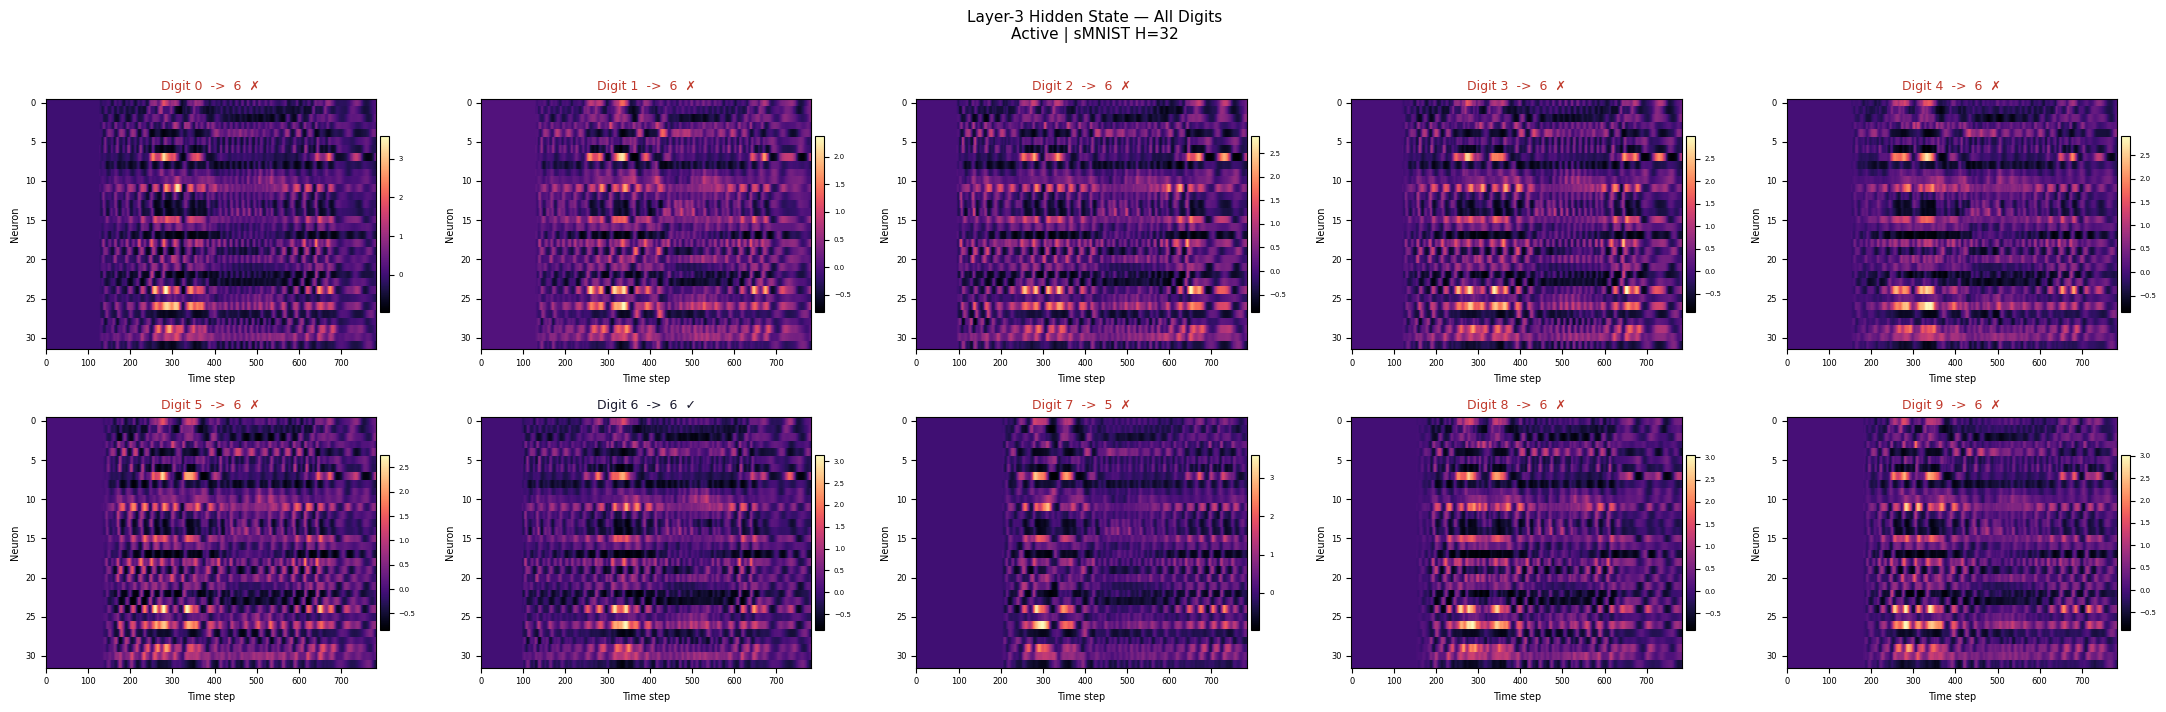

  Saved: /home/casper/Documents/A_Casper/Brein/CS_Ai_Wolfhampton/Dissertation/figures/fig_cross_digit_sMNIST-H32_Passive_L3.pdf


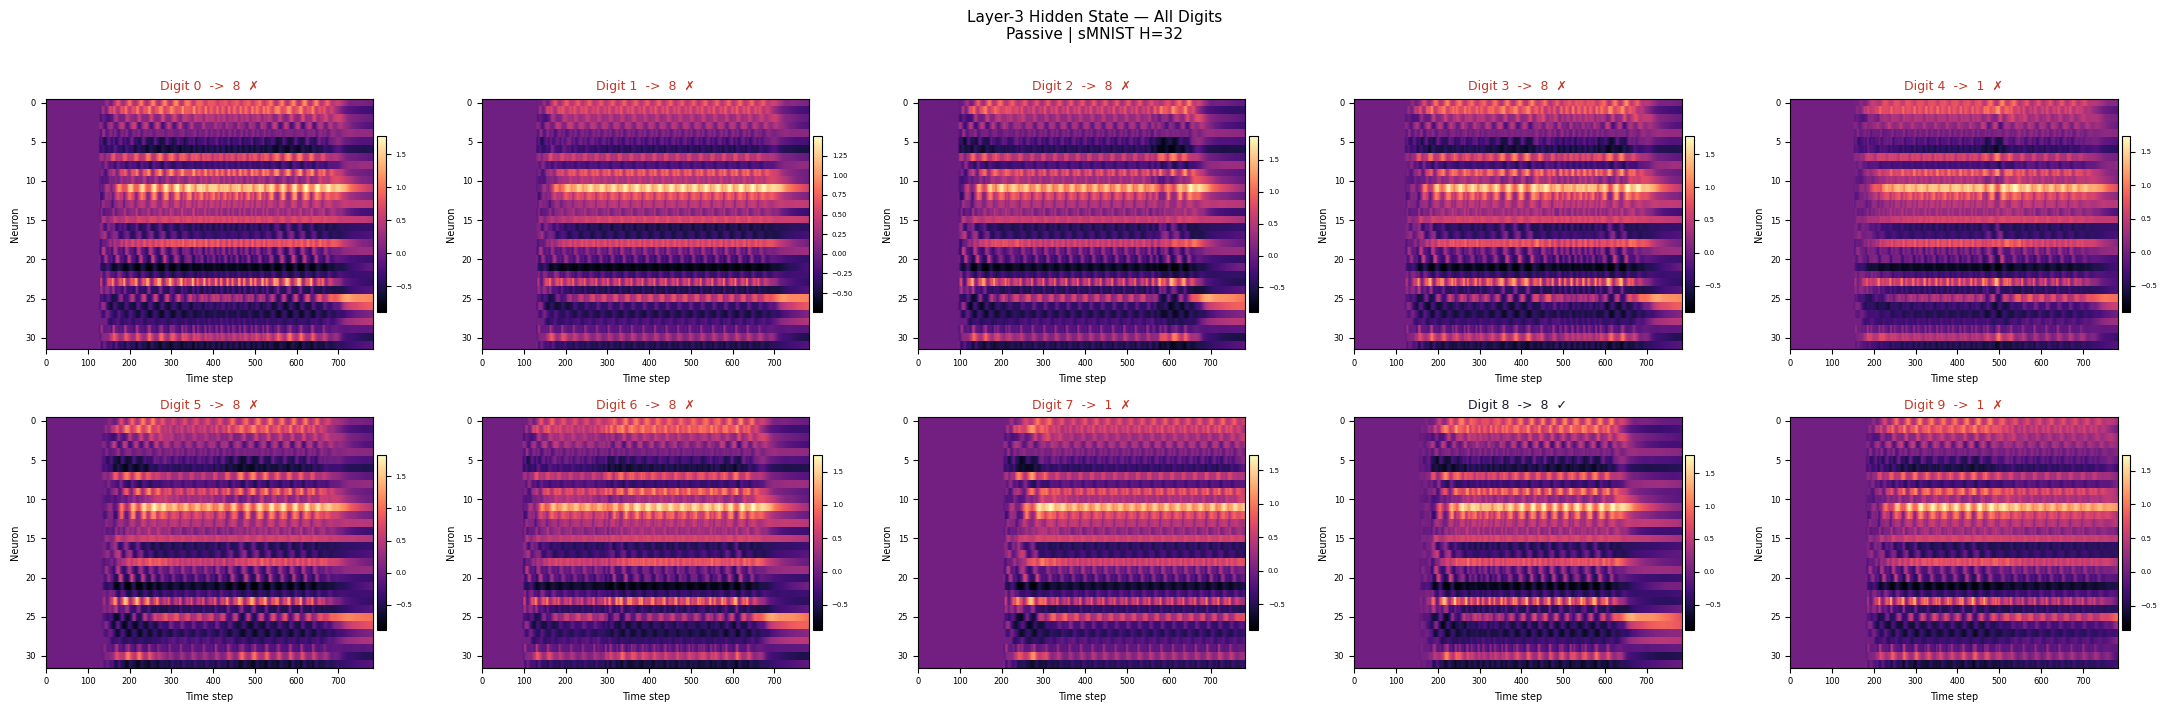

  Saved: /home/casper/Documents/A_Casper/Brein/CS_Ai_Wolfhampton/Dissertation/figures/fig_cross_digit_sMNIST-H32_Probe_L3.pdf


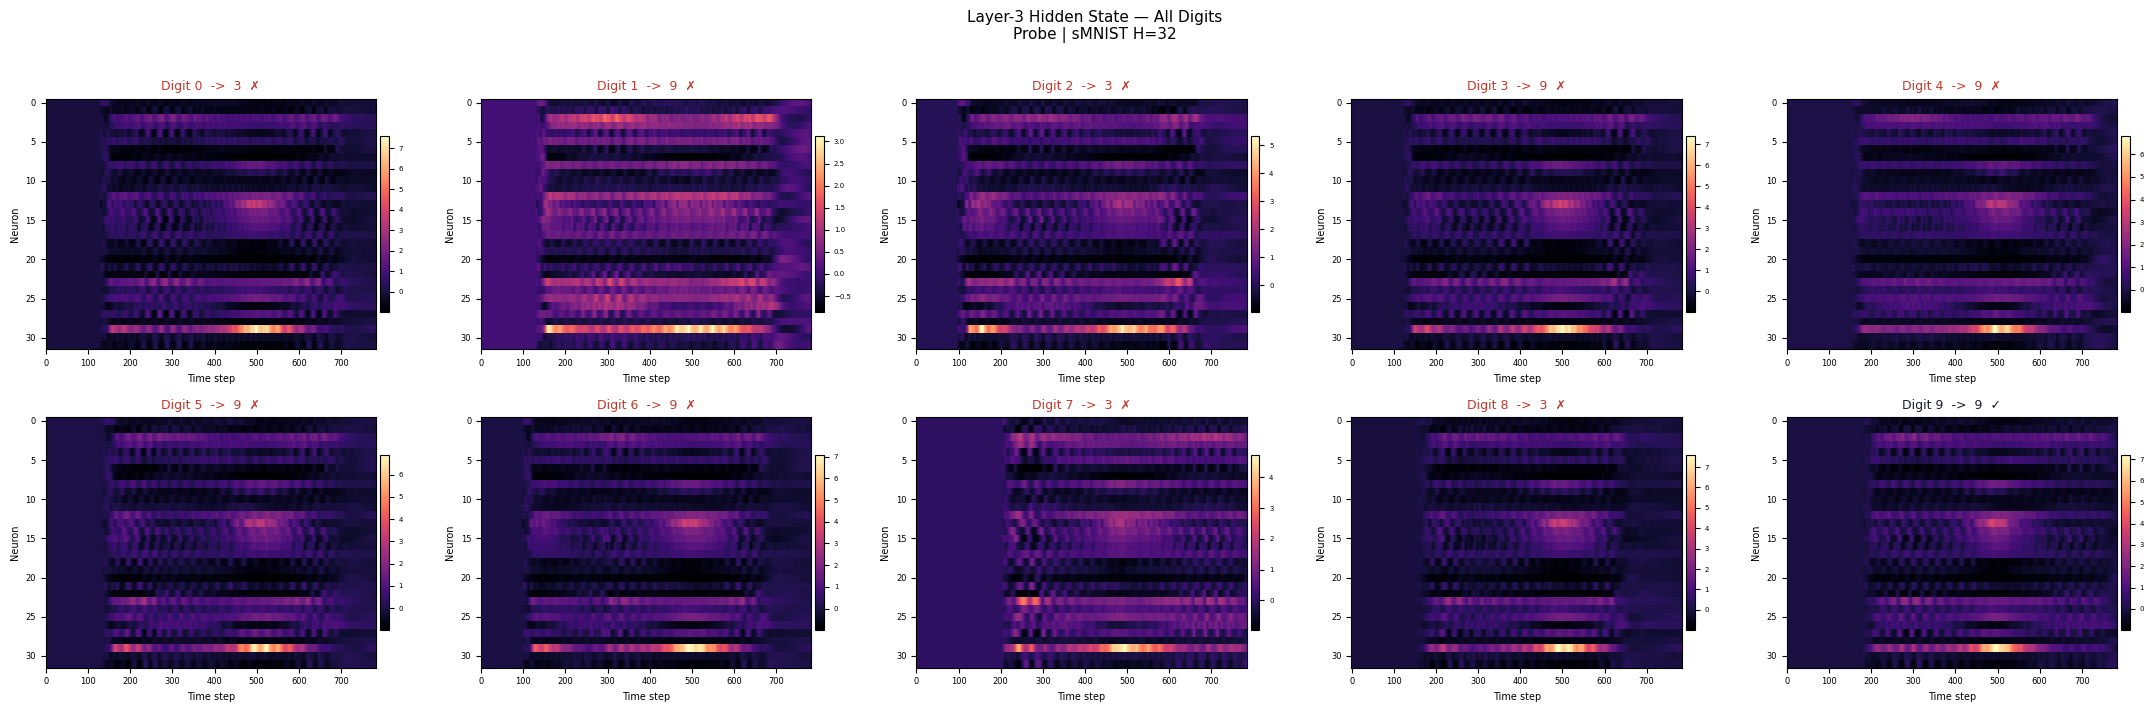

In [ ]:
def plot_cross_digit_overview(cfg_key, condition='Active', layer_idx=2):
    """Shows layer activity (neuron x time) for one sample per digit, side by side."""
    cfg  = CONFIGS[cfg_key]
    x_src = x_test_perm if cfg['permuted'] else x_test_seq

    d = RESULTS[cfg_key].get(condition)
    params = {
        'strength': d['config']['strength'] if d else cfg['hparams']['BASE_STRENGTH'],
        'period':   cfg['hparams'].get('PERIOD', 256.0),
        'lambda':   cfg['hparams'].get('LAMBDA_SLOW', 0.05),
        'inertia':  cfg['hparams'].get('H_INERTIA', 0.5),
        'jitter':   cfg['hparams'].get('JITTER_SCALE', 0.1),
    }

    tf.keras.backend.clear_session()
    model = OscillatingResonator(hidden=cfg['hidden'], params=params, mode=condition.lower())
    _ = model(tf.zeros((1, 784, 1)))
    wpath = os.path.join(cfg['folder'], cfg['weights'][condition])
    if os.path.exists(wpath):
        model.load_weights(wpath)

    fig, axes = plt.subplots(2, 5, figsize=(22, 7))
    axes = axes.flatten()

    for digit in range(10):
        idx   = DIGIT_INDICES[digit][0]
        img_t = tf.convert_to_tensor(x_src[idx:idx+1], dtype=tf.float32)

        logits, h_seq = model(img_t, training=False)

        if layer_idx == 0:
            h_np = model.rnn1(img_t, training=False)[0].numpy()
        elif layer_idx == 1:
            h1   = model.rnn1(img_t, training=False)
            h_np = model.rnn2(h1,    training=False)[0].numpy()
        else:
            h_np = h_seq[0].numpy()

        pred    = np.argmax(logits.numpy())
        correct = pred == digit

        ax = axes[digit]
        im = ax.imshow(h_np.T, aspect='auto', cmap='magma', interpolation='nearest')
        ax.set_title(f'Digit {digit}  ->  {pred}  {"✓" if correct else "✗"}',
                     fontsize=9, color='#1a1a2e' if correct else '#c0392b')
        ax.set_ylabel('Neuron', fontsize=7)
        ax.set_xlabel('Time step', fontsize=7)
        ax.tick_params(labelsize=6)
        plt.colorbar(im, ax=ax, shrink=0.7, pad=0.01).ax.tick_params(labelsize=5)

    bench = cfg['benchmark']
    h     = cfg['hidden']
    fig.suptitle(f'Layer-{layer_idx+1} Hidden State — All Digits\n'
                 f'{condition} | {bench} H={h}',
                 fontsize=11, y=1.01)
    fig.tight_layout()
    savefig(fig, f'fig_cross_digit_{cfg_key}_{condition}_L{layer_idx+1}')
    plt.show()


plot_cross_digit_overview('sMNIST-H32', condition='Active')
plot_cross_digit_overview('sMNIST-H32', condition='Passive')
plot_cross_digit_overview('sMNIST-H32', condition='Probe')

## 11. Figure — Reversal Robustness Check
Evaluates all three conditions on the standard and time-reversed test set.
Retention ratio = reversed_acc / standard_acc (1.0 = perfect memory-invariance).

In [ ]:
EVAL_BATCH = 256
EVAL_FRAC  = 0.1

def eval_standard_and_reversed(cfg_key):
    cfg      = CONFIGS[cfg_key]
    x_src    = x_test_perm if cfg.get('permuted', False) else x_test_seq
    num_test = int(len(x_src) * EVAL_FRAC)
    x_sub    = x_src[:num_test]
    y_sub    = y_test[:num_test]
    x_rev    = x_sub[:, ::-1, :]

    results = {}
    for cond in CONDITIONS:
        d = RESULTS[cfg_key].get(cond)
        params = {
            'strength': d['config']['strength'] if (d and 'config' in d) else cfg['hparams']['BASE_STRENGTH'],
            'period':   cfg['hparams'].get('PERIOD', 256.0),
            'lambda':   cfg['hparams'].get('LAMBDA_SLOW', 0.05),
            'inertia':  cfg['hparams'].get('H_INERTIA', 0.5),
            'jitter':   cfg['hparams'].get('JITTER_SCALE', 0.1),
        }

        tf.keras.backend.clear_session()
        model = OscillatingResonator(hidden=cfg['hidden'], params=params, mode=cond.lower())
        _ = model(tf.zeros((1, 784, 1)))
        wpath = os.path.join(cfg['folder'], cfg['weights'][cond])
        if os.path.exists(wpath):
            try:
                model.load_weights(wpath).expect_partial()
                print(f'  Loaded {cond} ({cfg_key}): {os.path.basename(wpath)}')
            except Exception as e:
                print(f'  Name-based load failed ({e}), trying positional...')
                load_weights_by_value(model, wpath)
        else:
            print(f'  [WARN] Not found: {wpath}')

        def get_acc(data):
            hits = 0
            for start in range(0, num_test, EVAL_BATCH):
                xb = data[start:start+EVAL_BATCH]
                yb = y_sub[start:start+EVAL_BATCH]
                logits, _ = model(tf.constant(xb, dtype=tf.float32), training=False)
                hits += np.sum(np.argmax(logits.numpy(), axis=-1) == yb)
            return (hits / num_test) * 100

        std_acc = get_acc(x_sub)
        rev_acc = get_acc(x_rev)
        results[cond] = {'std': std_acc, 'rev': rev_acc,
                         'ratio': rev_acc / (std_acc + 1e-9)}
        print(f'  {cond:7s} | Std: {std_acc:5.2f}% | Rev: {rev_acc:5.2f}% | Ratio: {results[cond]["ratio"]:.3f}')

    return results


rev_results = {}
for cfg_key in CONFIGS:
    print(f'\n[REVERSAL EVAL] {cfg_key}')
    rev_results[cfg_key] = eval_standard_and_reversed(cfg_key)


fig, axes = plt.subplots(1, 2, figsize=(14, 5))
x_pos = np.arange(len(CONDITIONS))

for ax_idx, (metric_key, ylabel, title) in enumerate([
    ('std',   'Accuracy (%)',    'Standard Test Accuracy'),
    ('ratio', 'Retention Ratio', 'Reversal Retention Ratio (rev/std)'),
]):
    ax       = axes[ax_idx]
    configs  = list(CONFIGS.keys())
    n_configs = len(configs)
    width    = 0.8 / n_configs

    for i, cfg_key in enumerate(configs):
        vals = [rev_results[cfg_key].get(cond, {}).get(metric_key, 0) for cond in CONDITIONS]
        pos  = x_pos - 0.4 + (i * width) + (width / 2)
        bars = ax.bar(pos, vals, width, label=cfg_key, alpha=0.85)
        for bar in bars:
            h = bar.get_height()
            ax.text(bar.get_x() + bar.get_width() / 2, h + (h * 0.01),
                    f'{h:.1f}' if metric_key == 'std' else f'{h:.2f}',
                    ha='center', va='bottom', fontsize=6)

    if metric_key == 'ratio':
        ax.axhline(1.0, color='red', ls=':', lw=1, alpha=0.5, label='Symmetry Line')

    ax.set_xticks(x_pos)
    ax.set_xticklabels(CONDITIONS)
    ax.set_ylabel(ylabel)
    ax.set_title(title, fontweight='bold')
    ax.legend(fontsize=7, frameon=False, loc='upper left')
    ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
savefig(fig, 'fig_reversal_robustness')
plt.show()


[REVERSAL EVAL] psMNIST-H32
ERROR:tensorflow:==================================
Object was never used (type <class 'tensorflow.python.ops.tensor_array_ops.TensorArray'>):
If you want to mark it as used call its "mark_used()" method.
It was originally created here:
  File "/home/casper/micromamba/envs/rs/lib/python3.11/site-packages/keras/src/backend/tensorflow/rnn.py", line 418, in <genexpr>
    output_ta_t = tuple(  File "/home/casper/micromamba/envs/rs/lib/python3.11/site-packages/tensorflow/python/util/tf_should_use.py", line 288, in wrapped
    return _add_should_use_warning(fn(*args, **kwargs),


TypeError: OscillatingResonator.__init__() got an unexpected keyword argument 'params'

## 12. Summary Table — All Configs, All Conditions

In [ ]:
# extract_series normalises to short keys: rank, sync, intf, acorr, entr
METRIC_COLS = [
    ('rank',  'Rank',    '>7.2f'),
    ('sync',  'Sync',    '>7.3f'),
    ('intf',  'Interf',  '>8.3f'),
    ('acorr', 'ACorr',   '>8.3f'),
    ('entr',  'Entropy', '>8.3f'),
]

print('=' * 105)
print(f'{"Config":<16} {"Cond":<9} {"Epochs":>7} {"TestAcc%":>9} '
      + ' '.join(f'{hdr:>{int(fmt[1:-2])+1}}' for _, hdr, fmt in METRIC_COLS))
print('-' * 105)

for cfg_key in CONFIGS:
    for cond in CONDITIONS:
        d = RESULTS[cfg_key].get(cond)
        if d is None:
            print(f'{cfg_key:<16} {cond:<9}  (no data)')
            continue
        e = len(d['epochs'])
        metric_str = ' '.join(
            format(d[key][-1], fmt) if key in d else format(float('nan'), fmt)
            for key, _, fmt in METRIC_COLS
        )
        print(f'{cfg_key:<16} {cond:<9} {e:>7} {d["test_acc"]:>9.2f} {metric_str}')
    print('-' * 105)

print('=' * 105)

ValueError: invalid literal for int() with base 10: '7.'

In [ ]:
import h5py

def inspect_weights(cfg_key, cond):
    cfg = CONFIGS[cfg_key]
    wpath = os.path.join(cfg['folder'], cfg['weights'][cond])
    print(f"\n=== {cfg_key} | {cond} ===")
    print(f"Path: {wpath}")
    with h5py.File(wpath, 'r') as f:
        f.visititems(lambda name, obj: print(f"  {name}: {obj.shape}" 
                                             if hasattr(obj, 'shape') else f"  {name}/"))

inspect_weights('psMNIST-H32', 'Passive')


=== psMNIST-H32 | Passive ===
Path: /home/casper/Documents/A_Casper/Brein/CS_Ai_Wolfhampton/Dissertation/PMNIST/h32/best_RES_H32_S0.13_J1_260222_1954_passive.weights.h5
  dense/
  dense/oscillating_resonator/
  dense/oscillating_resonator/dense/
  dense/oscillating_resonator/dense/bias:0: (10,)
  dense/oscillating_resonator/dense/kernel:0: (32, 10)
  jittered_feedback_cell/
  jittered_feedback_cell/oscillating_resonator/
  jittered_feedback_cell/oscillating_resonator/rnn/
  jittered_feedback_cell/oscillating_resonator/rnn/jittered_feedback_cell/
  jittered_feedback_cell/oscillating_resonator/rnn/jittered_feedback_cell/bias:0: (32,)
  jittered_feedback_cell/oscillating_resonator/rnn/jittered_feedback_cell/w_in:0: (1, 32)
  jittered_feedback_cell/oscillating_resonator/rnn/jittered_feedback_cell/w_rec:0: (32, 32)
  rnn/
  rnn/oscillating_resonator/
  rnn/oscillating_resonator/rnn/
  rnn/oscillating_resonator/rnn/jittered_feedback_cell/
  rnn/oscillating_resonator/rnn/jittered_feedback_ce

In [ ]:
import h5py
import numpy as np

def load_weights_by_value(model, wpath):
    """Load weights by shape-verified position, bypassing name/path matching."""
    with h5py.File(wpath, 'r') as f:
        arrays = []
        def collect(name, obj):
            if isinstance(obj, h5py.Dataset) and obj.ndim > 0:
                arrays.append((name, obj[:]))
        f.visititems(collect)

    model_weights = model.weights
    
    if len(arrays) != len(model_weights):
        print(f"  [WARN] count mismatch: file={len(arrays)}, model={len(model_weights)}")
        # Try matching by shape
        used = set()
        for w in model_weights:
            for i, (name, arr) in enumerate(arrays):
                if i not in used and w.shape == arr.shape:
                    w.assign(arr)
                    used.add(i)
                    break
        print(f"  Matched {len(used)}/{len(model_weights)} weights by shape")
        return
    
    mismatches = [(model_weights[i].name, model_weights[i].shape, arrays[i][1].shape)
                  for i in range(len(arrays)) if model_weights[i].shape != arrays[i][1].shape]
    if mismatches:
        print(f"  [ERROR] shape mismatches: {mismatches}")
        return
    
    for w, (name, arr) in zip(model_weights, arrays):
        w.assign(arr)
    print(f"  Loaded {len(arrays)} weights by position")

## Setup reversal and weight visualisation

In [ ]:
import os
import math
import h5py
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec




def savefig(fig, filename):
    """Helper to save figures without crashing if directory doesn't exist."""
    fig.savefig(f"{filename}.png", bbox_inches='tight', dpi=150)

def reconstruct_field_effect(h_layer, hparams):
    """
    Placeholder for your field effect reconstruction. 
    Returns dummy (sine, None, fe_mean) so plot_brain doesn't crash.
    """
    time_steps = h_layer.shape[1]
    t = np.arange(time_steps)
    period = hparams.get('period', 256.0)
    strength = hparams.get('strength', 0.1)
    sine = np.sin(2 * np.pi * t / period)
    fe_mean = 1.0 + (strength * sine) # Simplified dummy reconstruction
    return sine, None, fe_mean

# =============================================================================
# 2. DATASET PREPARATION
# =============================================================================
(x_all, y_all), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

x_all  = x_all.reshape(-1, 784).astype('float32') / 255.0
x_test = x_test.reshape(-1, 784).astype('float32') / 255.0

# Fixed permutation (seed 42) — same as training
rng  = np.random.RandomState(42)
PERM = rng.permutation(784)
INV_PERM = np.argsort(PERM)

x_test_seq = x_test[:, :, np.newaxis].astype('float32')  # sequential (sMNIST)
x_test_perm = x_test[:, PERM, np.newaxis].astype('float32')  # permuted (psMNIST)
y_test = y_test.astype('int32')

# Collect one representative sample per digit (test set)
DIGIT_INDICES = {}
for digit in range(10):
    idxs = np.where(y_test == digit)[0]
    DIGIT_INDICES[digit] = idxs[:5]  # first 5 per digit

print(f'Test set: {x_test.shape}, digit samples ready.')

# =============================================================================
# 3. MODEL ARCHITECTURE
# =============================================================================
class JitteredFeedbackCell(tf.keras.layers.Layer):
    def __init__(self, units=16, strength=0.0, period=256.0,
                 lambda_slow=0.05, h_inertia=0.5, jitter_scale=0.1, 
                 rest_baseline=1.0, mode='active', **kwargs):
        super().__init__(**kwargs)
        self.units       = units
        self.state_size  = [units, units, 1] # h, G, phase
        self.strength    = strength
        self.period      = period
        self.lambda_slow = lambda_slow
        self.h_scale     = [h_inertia, 1.0 - h_inertia]
        self.jitter_scale = jitter_scale
        self.rest_baseline = rest_baseline
        self.mode        = mode

    def build(self, input_shape):
        self.w_in = self.add_weight(shape=(input_shape[-1], self.units), name='w_in', initializer='glorot_uniform')
        self.w_rec = self.add_weight(shape=(self.units, self.units), name='w_rec', initializer=tf.keras.initializers.Orthogonal(gain=1.0))
        self.bias = self.add_weight(shape=(self.units,), name='bias', initializer='zeros')

    def call(self, inputs, states):
        prev_h, prev_G, prev_phase = states
        
        half = self.units // 2
        raw_signal = tf.concat([prev_h[:, half:], prev_h[:, :half]], axis=1)
        source = tf.stop_gradient(raw_signal) if self.mode == 'probe' else raw_signal
        
        new_G = (1.0 - self.lambda_slow) * prev_G + self.lambda_slow * source
        G_norm = (new_G - tf.reduce_mean(new_G, axis=-1, keepdims=True)) / (tf.math.reduce_std(new_G, axis=-1, keepdims=True) + 1e-6)
        
        new_phase = prev_phase + (2.0 * math.pi / self.period)
        oscillator = tf.math.sin(new_phase)
        
        if self.mode == 'active':
            bias_sig = tf.reduce_mean(source, axis=-1, keepdims=True) - 0.1
            combined = oscillator + (self.jitter_scale * bias_sig)
        else:
            combined = oscillator
            
        strength_val = self.strength * combined if self.mode != 'passive' else 0.0
        field_effect = self.rest_baseline + (strength_val * tf.tanh(G_norm))
        
        z = (tf.matmul(inputs, self.w_in) + tf.matmul(prev_h, self.w_rec) + self.bias) * field_effect
        h = (self.h_scale[0] * prev_h) + (self.h_scale[1] * tf.nn.elu(z))
        h = tf.clip_by_value(h, -20.0, 20.0)
        
        return h, [h, new_G, new_phase]

class OscillatingResonator(tf.keras.Model):
    def __init__(self, hidden=16, num_classes=10, params=None, mode="active"):
        super().__init__()
        p = params if params else {}
        cell_kwargs = {
            'units': hidden,
            'strength': p.get('strength', 0.0),
            'period': p.get('period', 256.0),
            'lambda_slow': p.get('lambda', 0.05),
            'h_inertia': p.get('inertia', 0.5),
            'jitter_scale': p.get('jitter', 0.1),
            'mode': mode
        }

        # Explicitly matching internal structure
        self.rnn1 = tf.keras.layers.RNN(JitteredFeedbackCell(**cell_kwargs, name="cell"), return_sequences=True, name="rnn")
        self.rnn2 = tf.keras.layers.RNN(JitteredFeedbackCell(**cell_kwargs), return_sequences=True, name="rnn_1")
        self.rnn3 = tf.keras.layers.RNN(JitteredFeedbackCell(**cell_kwargs), return_sequences=True, name="rnn_2")
        self.out = tf.keras.layers.Dense(num_classes, dtype='float32', name="dense")

    def call(self, x, training=False):
        h1 = self.rnn1(x, training=training)
        h2 = self.rnn2(h1, training=training)
        h3 = self.rnn3(h2, training=training)
        return self.out(h3[:, -1, :]), h3

# =============================================================================
# 4. ROBUST WEIGHT LOADER
# =============================================================================
def robust_load_weights(model, wpath):
    """Loads weights positionally, avoiding Keras double-tracking duplicates."""
    with h5py.File(wpath, 'r') as f:
        arrays = []
        def collect(name, obj):
            if isinstance(obj, h5py.Dataset) and obj.ndim > 0:
                top_level = name.split('/')[0]
                if top_level in ['rnn', 'rnn_1', 'rnn_2', 'dense']:
                    arrays.append((name, obj[:]))
        f.visititems(collect)

    def sort_key(item):
        name = item[0]
        if name.startswith('rnn/'): layer_idx = 0
        elif name.startswith('rnn_1/'): layer_idx = 1
        elif name.startswith('rnn_2/'): layer_idx = 2
        elif name.startswith('dense/'): layer_idx = 3
        else: layer_idx = 4
        
        if 'w_in' in name or 'kernel' in name: comp_idx = 0
        elif 'w_rec' in name: comp_idx = 1
        elif 'bias' in name: comp_idx = 2
        else: comp_idx = 3
        return (layer_idx, comp_idx)
        
    arrays.sort(key=sort_key)
    model_weights = model.weights
    
    if len(arrays) != len(model_weights):
        print(f"  [ERROR] Mismatch: {len(arrays)} file arrays vs {len(model_weights)} model weights.")
        return

    for w, (name, arr) in zip(model_weights, arrays):
        if w.shape == arr.shape:
            w.assign(arr)
        else:
            print(f"  [ERROR] Shape conflict at {w.name} ({w.shape}) vs {name} ({arr.shape})")
            return
    print(f"  Loaded {len(arrays)} weights via robust mapping.")

def build_and_load(cfg_key, cond):
    """Standardizes model initialization, graph tracing, and weight loading."""
    cfg = CONFIGS[cfg_key]
    d = RESULTS[cfg_key].get(cond, {})
    
    strength = d.get('config', {}).get('strength', cfg['hparams'].get('BASE_STRENGTH', 0.0))
    params = {
        'strength': strength,
        'period':   cfg['hparams'].get('PERIOD', 256.0),
        'lambda':   cfg['hparams'].get('LAMBDA_SLOW', 0.05),
        'inertia':  cfg['hparams'].get('H_INERTIA', 0.5),
        'jitter':   cfg['hparams'].get('JITTER_SCALE', 0.1),
    }

    model = OscillatingResonator(hidden=cfg['hidden'], params=params, mode=cond.lower())
    _ = model(tf.zeros((1, 784, 1))) # Force variable creation
    
    wpath = os.path.join(cfg['folder'], cfg['weights'][cond])
    if os.path.exists(wpath):
        try:
            model.load_weights(wpath).expect_partial()
        except Exception:
            robust_load_weights(model, wpath)
    else:
        print(f"  [WARN] File not found: {wpath}")
        
    return model


Test set: (10000, 784), digit samples ready.


In [ ]:
def eval_standard_and_reversed(cfg_key, eval_batch=256, eval_frac=0.1):
    cfg      = CONFIGS[cfg_key]
    x_src    = x_test_perm if cfg.get('permuted', False) else x_test_seq
    num_test = int(len(x_src) * eval_frac)
    x_sub    = x_src[:num_test]
    y_sub    = y_test[:num_test]
    x_rev    = x_sub[:, ::-1, :]

    results = {}
    for cond in CONDITIONS:
        tf.keras.backend.clear_session()
        print(f"Loading {cond} for Reversal Eval...")
        model = build_and_load(cfg_key, cond)

        def get_acc(data):
            hits = 0
            for start in range(0, num_test, eval_batch):
                xb = data[start:start+eval_batch]
                yb = y_sub[start:start+eval_batch]
                logits, _ = model(tf.constant(xb, dtype=tf.float32), training=False)
                hits += np.sum(np.argmax(logits.numpy(), axis=-1) == yb)
            return (hits / num_test) * 100

        std_acc = get_acc(x_sub)
        rev_acc = get_acc(x_rev)
        results[cond] = {'std': std_acc, 'rev': rev_acc, 'ratio': rev_acc / (std_acc + 1e-9)}
        print(f'  {cond:7s} | Std: {std_acc:5.2f}% | Rev: {rev_acc:5.2f}% | Ratio: {results[cond]["ratio"]:.3f}')

    return results

In [ ]:
def plot_cross_digit_overview(cfg_key, condition='Active', layer_idx=2):
    cfg  = CONFIGS[cfg_key]
    x_src = x_test_perm if cfg['permuted'] else x_test_seq

    tf.keras.backend.clear_session()
    model = build_and_load(cfg_key, condition)

    fig, axes = plt.subplots(2, 5, figsize=(22, 7))
    axes = axes.flatten()

    for digit in range(10):
        idx   = DIGIT_INDICES[digit][0]
        img_t = tf.convert_to_tensor(x_src[idx:idx+1], dtype=tf.float32)

        logits, h_seq = model(img_t, training=False)

        if layer_idx == 0:
            h_np = model.rnn1(img_t, training=False)[0].numpy()
        elif layer_idx == 1:
            h1   = model.rnn1(img_t, training=False)
            h_np = model.rnn2(h1,    training=False)[0].numpy()
        else:
            h_np = h_seq[0].numpy()

        pred    = np.argmax(logits.numpy())
        correct = pred == digit

        ax = axes[digit]
        im = ax.imshow(h_np.T, aspect='auto', cmap='magma', interpolation='nearest')
        ax.set_title(f'Digit {digit}  ->  {pred}  {"✓" if correct else "✗"}',
                     fontsize=9, color='#1a1a2e' if correct else '#c0392b')
        ax.set_ylabel('Neuron', fontsize=7)
        ax.set_xlabel('Time step', fontsize=7)
        ax.tick_params(labelsize=6)
        plt.colorbar(im, ax=ax, shrink=0.7, pad=0.01).ax.tick_params(labelsize=5)

    fig.suptitle(f'Layer-{layer_idx+1} Hidden State — All Digits\n{condition} | {cfg["benchmark"]} H={cfg["hidden"]}', fontsize=11, y=1.01)
    fig.tight_layout()
    savefig(fig, f'fig_cross_digit_{cfg_key}_{condition}_L{layer_idx+1}')
    plt.show()


In [ ]:
def eval_standard_and_reversed(cfg_key):
    cfg      = CONFIGS[cfg_key]
    x_src    = x_test_perm if cfg.get('permuted', False) else x_test_seq
    num_test = int(len(x_src) * EVAL_FRAC)
    x_sub    = x_src[:num_test]
    y_sub    = y_test[:num_test]
    x_rev    = x_sub[:, ::-1, :]

    results = {}
    for cond in CONDITIONS:
        tf.keras.backend.clear_session()
        print(f"Loading {cond} for Reversal Eval...")
        model = build_and_load(cfg_key, cond)

        def get_acc(data):
            hits = 0
            for start in range(0, num_test, EVAL_BATCH):
                xb = data[start:start+EVAL_BATCH]
                yb = y_sub[start:start+EVAL_BATCH]
                logits, _ = model(tf.constant(xb, dtype=tf.float32), training=False)
                hits += np.sum(np.argmax(logits.numpy(), axis=-1) == yb)
            return (hits / num_test) * 100

        std_acc = get_acc(x_sub)
        rev_acc = get_acc(x_rev)
        results[cond] = {'std': std_acc, 'rev': rev_acc,
                         'ratio': rev_acc / (std_acc + 1e-9)}
        print(f'  {cond:7s} | Std: {std_acc:5.2f}% | Rev: {rev_acc:5.2f}% | Ratio: {results[cond]["ratio"]:.3f}')

    return results

In [ ]:

def plot_brain(cfg_key, digit=3, sample_idx=0, layer=2):
    cfg = CONFIGS[cfg_key]
    permuted = cfg.get('permuted', False)
    x_src = x_test_perm if permuted else x_test_seq

    idx = DIGIT_INDICES[digit][sample_idx]
    img_seq = x_src[idx:idx+1]
    img_disp = x_test[idx].reshape(28, 28)

    fig = plt.figure(figsize=(20, 4 * len(CONDITIONS)))
    outer_gs = gridspec.GridSpec(len(CONDITIONS), 1, hspace=0.4)

    for row_i, cond in enumerate(CONDITIONS):
        inner_gs = gridspec.GridSpecFromSubplotSpec(
            1, 6, subplot_spec=outer_gs[row_i],
            width_ratios=[0.6, 3, 3, 3, 2, 2], wspace=0.3
        )

        tf.keras.backend.clear_session()
        model = build_and_load(cfg_key, cond)

        img_t = tf.convert_to_tensor(img_seq, dtype=tf.float32)
        logits, _ = model(img_t, training=False)
        
        h1 = model.rnn1(img_t, training=False)
        h2 = model.rnn2(h1, training=False)
        h3 = model.rnn3(h2, training=False)
        h_layers = [h1[0].numpy(), h2[0].numpy(), h3[0].numpy()]
        
        pred = np.argmax(logits.numpy(), axis=-1)[0]
        correct = (pred == digit)

        ax0 = fig.add_subplot(inner_gs[0])
        ax0.imshow(img_disp, cmap='gray')
        ax0.set_title(f'{cond}\nPred: {pred}', color='green' if correct else 'red', fontsize=10)
        ax0.axis('off')

        for li, (h_data, lbl) in enumerate(zip(h_layers, ['L1', 'L2', 'L3'])):
            ax = fig.add_subplot(inner_gs[li + 1])
            ax.imshow(h_data.T, aspect='auto', cmap='magma')
            ax.set_title(lbl, fontsize=9)
            if li == 1: ax.set_xlabel('Time Steps', fontsize=8)

        ax_pm = fig.add_subplot(inner_gs[4])
        pop_mean = np.mean(h_layers[layer], axis=-1)
        ax_pm.plot(pop_mean, color=COLORS[cond], lw=1.5)
        ax_pm.set_title('Avg Activity μ(h)', fontsize=9)

        ax_fe = fig.add_subplot(inner_gs[5])
        hparams = cfg['hparams'].copy()
        d = RESULTS[cfg_key].get(cond, {})
        if d and 'config' in d: hparams['strength'] = d['config'].get('strength', hparams.get('BASE_STRENGTH'))
            
        sine, _, fe_mean = reconstruct_field_effect(h_layers[layer], hparams)
        ax_fe.plot(sine, color='gray', alpha=0.3, ls='--', label='Osc')
        ax_fe.plot(fe_mean, color=COLORS[cond], lw=1.5, label='GF')
        ax_fe.set_title('Reconstructed GF', fontsize=9)

    plt.suptitle(f"Neural Dynamics: {cfg_key} (Digit {digit})", y=1.02, fontsize=14, fontweight='bold')
    plt.show()


In [ ]:
def get_saliency(model, img_seq_tensor, label_idx):
    img_t = tf.Variable(img_seq_tensor)
    with tf.GradientTape() as tape:
        logits, _ = model(img_t, training=False)
        loss = logits[0, label_idx]
    grads = tape.gradient(loss, img_t)
    return tf.reduce_max(tf.abs(grads), axis=-1).numpy().flatten()

def plot_saliency_grid(cfg_key, digits=range(10), sample_idx=0):
    cfg = CONFIGS[cfg_key]
    permuted = cfg['permuted']
    x_src = x_test_perm if permuted else x_test_seq

    models = {}
    for cond in CONDITIONS:
        tf.keras.backend.clear_session()
        models[cond] = build_and_load(cfg_key, cond)

    digits = list(digits)
    n_cond = len(CONDITIONS)
    fig, axes = plt.subplots(len(digits), n_cond * 2, figsize=(n_cond * 4, len(digits) * 1.9))
    fig.subplots_adjust(hspace=0.05, wspace=0.05)

    for row_i, digit in enumerate(digits):
        idx = DIGIT_INDICES[digit][sample_idx]
        img_seq = x_src[idx:idx+1]
        img_clean = x_test[idx].reshape(28, 28)

        for col_i, cond in enumerate(CONDITIONS):
            model = models[cond]
            img_t = tf.convert_to_tensor(img_seq, dtype=tf.float32)
            sal = get_saliency(model, img_t, digit)
            sal_img = sal[INV_PERM].reshape(28, 28) if permuted else sal.reshape(28, 28)

            ax_img = axes[row_i, col_i * 2]
            ax_sal = axes[row_i, col_i * 2 + 1]

            ax_img.imshow(img_clean, cmap='gray', vmin=0, vmax=1)
            ax_sal.imshow(sal_img, cmap='hot', vmin=0)

            for ax in [ax_img, ax_sal]: ax.axis('off')

            if row_i == 0:
                ax_img.set_title(f'{cond}\nInput', fontsize=8)
                ax_sal.set_title(f'{cond}\nSaliency', fontsize=8)

            if col_i == 0:
                ax_img.set_ylabel(f'Digit {digit}', fontsize=8, rotation=0, labelpad=30, va='center')

    fig.suptitle(f"Saliency Maps — {cfg['benchmark']} H={cfg['hidden']}", fontsize=11, y=1.01)
    savefig(fig, f'fig_saliency_{cfg_key}')
    plt.show()






## Plotting execution

In [ ]:
# =============================================================================
# EXECUTION FOR psMNIST-H32
# =============================================================================

# 1. Saliency Grid: Visualizes what the model "sees" across all conditions for all digits
print("\nGenerating Saliency Grid for psMNIST-H32...")
plot_saliency_grid('psMNIST-H32', digits=range(10), sample_idx=0)

In [ ]:
# 2. Brain/Dynamics Plot: Inspects internal hidden states and Global Field (GF) 
# reconstruction for a specific digit (e.g., Digit 6)
print("\nGenerating Neural Dynamics Plot for Digit 6...")
plot_brain('psMNIST-H32', digit=6, sample_idx=0)

In [ ]:
# 3. Cross-Digit Hidden State Overview: Compares hidden layer representations 
# across all digits for the 'Active' condition
print("\nGenerating Cross-Digit Hidden State Overview (Active condition)...")
plot_cross_digit_overview('psMNIST-H32', condition='Active', layer_idx=2)


In [ ]:
# 4. Temporal Reversal Evaluation: Quantifies how dependent the model is on 
# temporal order (Standard vs. Reversed sequence)
print("\nRunning Reversal Evaluation for psMNIST-H32...")
rev_stats = eval_standard_and_reversed('psMNIST-H32')


Running Reversal Evaluation for psMNIST-H32...
ERROR:tensorflow:==================================
Object was never used (type <class 'tensorflow.python.ops.tensor_array_ops.TensorArray'>):
If you want to mark it as used call its "mark_used()" method.
It was originally created here:
  File "/home/casper/micromamba/envs/rs/lib/python3.11/site-packages/keras/src/backend/tensorflow/rnn.py", line 418, in <genexpr>
    output_ta_t = tuple(  File "/home/casper/micromamba/envs/rs/lib/python3.11/site-packages/tensorflow/python/util/tf_should_use.py", line 288, in wrapped
    return _add_should_use_warning(fn(*args, **kwargs),
Loading Passive for Reversal Eval...
  Loaded 11 weights via robust mapping.
  Passive | Std:  9.00% | Rev:  7.30% | Ratio: 0.811
Loading Probe for Reversal Eval...
  Loaded 11 weights via robust mapping.
  Probe   | Std:  9.00% | Rev: 10.90% | Ratio: 1.211
Loading Active for Reversal Eval...
  Loaded 11 weights via robust mapping.


KeyboardInterrupt: 